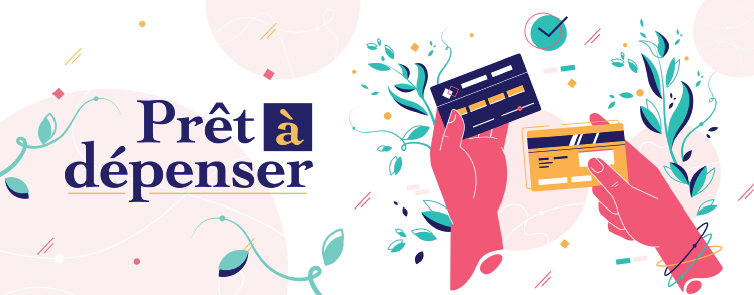

In [1]:
# %load_ext pycodestyle_magic
# %pycodestyle_on
# %pycodestyle_off

In [2]:
# utilities
import sys
import datetime

# data processing & cleaning
import pandas as pd
import numpy as np
import missingno as msno

# data viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FormatStrFormatter
# from jupyter_datatables import init_datatables_mode

# custom user functions
from functions import *

# serialization
import pickle

# set dataframe display options
pd.set_option('max_colwidth', None)
pd.set_option('display.max_columns', None)

# silence warnings after checking
import warnings
pd.set_option('future.no_silent_downcasting', False)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# extract colors from logo for ppt slideshow
light_pink = findColor('light_pink.png')
bright_pink = findColor('bright_pink.png')
# navy = findColor('navy.png')
sand = findColor('sand.png')
leaf = findColor('leaf.png')

print("light_pink hex :", light_pink)
print("bright_pink hex :", bright_pink)
print("navy hex : #242164")
print("sand hex :", sand)
print("leaf hex :", leaf)

light_pink hex : #fbf0ef
bright_pink hex : #f05876
navy hex : #242164
sand hex : #f1bd5f
leaf hex : #2fbeb5


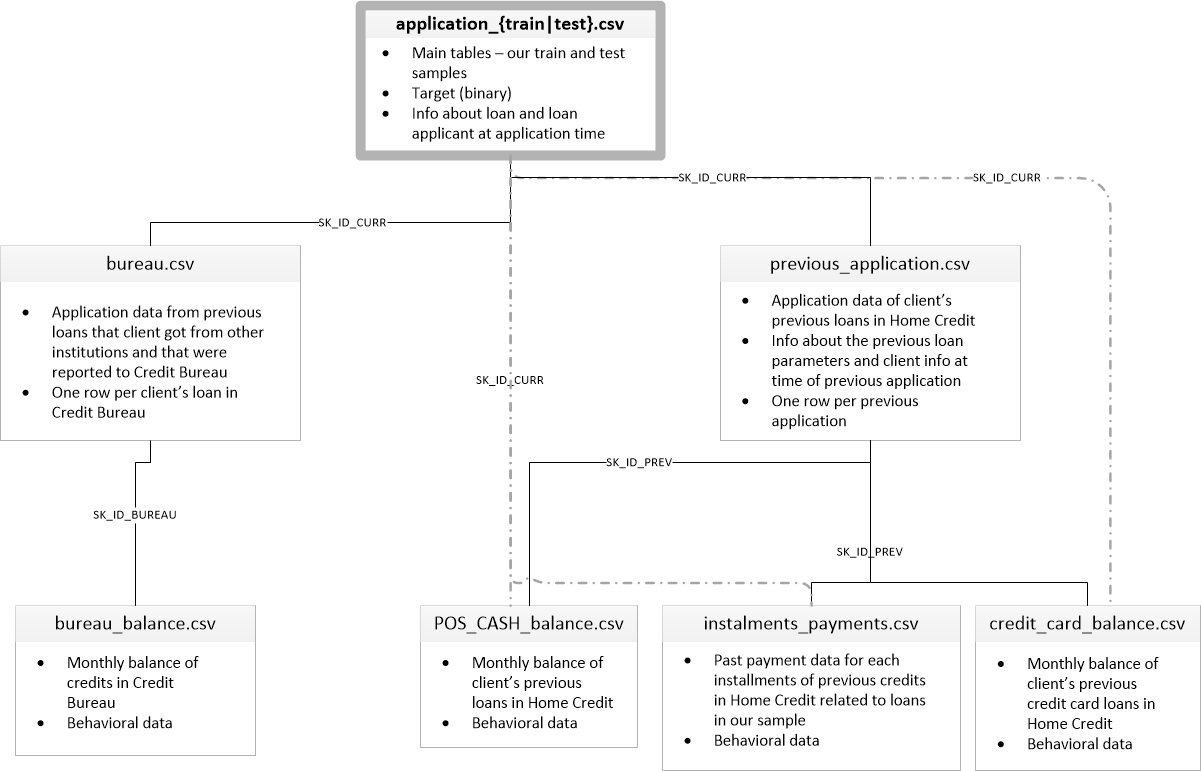

# 1 - Data imports, cleaning & initial feature selection

## 1.1 - Import data description

In [4]:
data_dico = pd.read_csv('HomeCredit_columns_description.csv', sep=',', encoding='latin-1')
print(data_dico.shape)
data_dico.head()

(219, 5)


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


## 1.2 - File bureau_balance.csv

In [5]:
# import file and check size
bureau_balance = pd.read_csv('bureau_balance.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(bureau_balance.shape)

(27299925, 3)


In [6]:
# check sample data
bureau_balance.sample(5)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
9095623,6146878,-94,C
25472110,6653732,-13,C
26055357,5068638,-29,C
16177837,6229834,-33,C
5829002,6523874,-95,C


In [7]:
# import data dictionary
bureau_balance_dico = data_dico.loc[data_dico['Table'] == 'bureau_balance.csv'][['Row', 'Description', 'Special']]
bureau_balance_dico

,Row,Description,Special
139,SK_BUREAU_ID,Recoded ID of Credit Bureau credit (unique coding for each application) - use this to join to CREDIT_BUREAU table,hashed
140,MONTHS_BALANCE,Month of balance relative to application date (-1 means the freshest balance date),time only relative to the application
141,STATUS,"Status of Credit Bureau loan during the month (active, closed, DPD0-30, [C means closed, X means status unknown, 0 means no DPD, 1 means maximal did during month between 1-30, 2 means DPD 31-60, 5 means DPD 120+ or sold or written off ] )",NaN


In [8]:
# check for NaNs
bureau_balance.isna().sum().sum() / (bureau_balance.shape[0] * bureau_balance.shape[1])

np.float64(0.0)

In [9]:
# feature engineering
bureau_balance.loc[((bureau_balance['STATUS'] == 'C') | (bureau_balance['STATUS'] == 'X') 
                   | (bureau_balance['STATUS'] == '0')), 'bb_DPD'] = 0  # assume no DPD
bureau_balance.loc[bureau_balance['STATUS'] == '1', 'bb_DPD'] = 15  # replace with middle of DPD 1-30 interval
bureau_balance.loc[bureau_balance['STATUS'] == '2', 'bb_DPD'] = 45  # replace with middle of DPD 31-60 interval
bureau_balance.loc[bureau_balance['STATUS'] == '3', 'bb_DPD'] = 75  # replace with middle of DPD 61-90 interval
bureau_balance.loc[bureau_balance['STATUS'] == '4', 'bb_DPD'] = 105  # replace with middle of DPD 91-120 interval
bureau_balance.loc[bureau_balance['STATUS'] == '5', 'bb_DPD'] = 135  # replace with middle of DPD 120-150 interval

# check
bureau_balance['bb_DPD'].isna().sum()

np.int64(0)

In [10]:
# remove redundant columns
bureau_balance.drop(labels=['STATUS'], axis=1, inplace=True) # column replaced with engineered features

In [11]:
# define aggregations
agg_dict_1_2= {'MONTHS_BALANCE': ['max'], # return date of freshest balance available
             'bb_DPD' : ['mean'] # return average number of DPD for each credit with another financial institution over lifetime of such credit
            }

In [12]:
# apply aggregations
grouped_data_1_2 = bureau_balance.groupby('SK_ID_BUREAU').agg(agg_dict_1_2).reset_index()
print(grouped_data_1_2.shape)
grouped_data_1_2.sample(5)

(817395, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,bb_DPD
,,max,mean
560061,6317413,-54,0.000000
590610,6387645,0,0.000000
609874,6424048,0,0.357143
4192,5008808,0,0.000000
345305,5969159,0,0.000000


In [13]:
# rename columns
grouped_data_1_2.rename(columns={'SK_ID_BUREAU':'bb_SK_ID_BUREAU','MONTHS_BALANCE':'bb_MONTHS_BALANCE_max',
                               'bb_DPD':'bb_DPD_mean'}, inplace=True)

# drop multi-index on columns
grouped_data_1_2 = grouped_data_1_2.droplevel(1, axis=1)

# check
grouped_data_1_2.head()

,bb_SK_ID_BUREAU,bb_MONTHS_BALANCE_max,bb_DPD_mean
0,5001709,0,0.0
1,5001710,0,0.0
2,5001711,0,0.0
3,5001712,0,0.0
4,5001713,0,0.0


In [14]:
grouped_data_1_2.isna().sum().sum() / (grouped_data_1_2.shape[0] * grouped_data_1_2.shape[1])

np.float64(0.0)

## 1.3 - File bureau.csv

In [15]:
# import file and check size
bureau_raw = pd.read_csv('bureau.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(bureau_raw.shape)

(1716428, 17)


In [16]:
# join bureau w/ bureau_balance
bureau = bureau_raw.merge(grouped_data_1_2, how='left', left_on='SK_ID_BUREAU', right_on='bb_SK_ID_BUREAU')

In [17]:
# check sample data
bureau.sample(5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,bb_SK_ID_BUREAU,bb_MONTHS_BALANCE_max,bb_DPD_mean
1461829,382647,5365821,Closed,currency 1,-2901,0,-2567.0,-2596.0,0.0,0,37144.8,0.0,0.0,0.0,Consumer credit,-2596,NaN,NaN,NaN,NaN
579739,381955,6307878,Active,currency 1,-1011,0,632.0,NaN,NaN,0,2214000.0,1100479.5,0.0,0.0,Consumer credit,-40,NaN,NaN,NaN,NaN
324913,107827,5536547,Closed,currency 1,-921,0,-699.0,-699.0,NaN,0,45000.0,0.0,0.0,0.0,Credit card,-539,0.0,5536547.0,0.0,0.0
434078,434207,5506873,Closed,currency 1,-2157,0,-1956.0,-922.0,NaN,0,135000.0,NaN,NaN,0.0,Consumer credit,-919,NaN,NaN,NaN,NaN
752395,211030,6633983,Closed,currency 1,-2014,0,-1941.0,-1941.0,NaN,0,44100.0,NaN,NaN,0.0,Consumer credit,-1936,NaN,NaN,NaN,NaN


In [18]:
# import data dictionary
bureau_dico = data_dico.loc[data_dico['Table'] == 'bureau.csv'][['Row', 'Description', 'Special']]
bureau_dico

,Row,Description,Special
122,SK_ID_CURR,"ID of loan in our sample - one loan in our sample can have 0,1,2 or more related previous credits in credit bureau",hashed
123,SK_BUREAU_ID,Recoded ID of previous Credit Bureau credit related to our loan (unique coding for each loan application),hashed
124,CREDIT_ACTIVE,Status of the Credit Bureau (CB) reported credits,NaN
125,CREDIT_CURRENCY,Recoded currency of the Credit Bureau credit,recoded
126,DAYS_CREDIT,How many days before current application did client apply for Credit Bureau credit,time only relative to the application
127,CREDIT_DAY_OVERDUE,Number of days past due on CB credit at the time of application for related loan in our sample,NaN
128,DAYS_CREDIT_ENDDATE,Remaining duration of CB credit (in days) at the time of application in Home Credit,time only relative to the application
129,DAYS_ENDDATE_FACT,Days since CB credit ended at the time of application in Home Credit (only for closed credit),time only relative to the application
130,AMT_CREDIT_MAX_OVERDUE,Maximal amount overdue on the Credit Bureau credit so far (at application date of loan in our sample),NaN
131,CNT_CREDIT_PROLONG,How many times was the Credit Bureau credit prolonged,NaN


In [19]:
# check for NaNs
bureau.isna().sum().sum() / (bureau.shape[0] * bureau.shape[1])

np.float64(0.1971002861757091)

In [20]:
bureau.sample(5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,bb_SK_ID_BUREAU,bb_MONTHS_BALANCE_max,bb_DPD_mean
69049,223984,5009016,Closed,currency 1,-734,0,-367.0,-367.0,NaN,0,155830.5,0.0,NaN,0.0,Consumer credit,-270,NaN,5009016.0,0.0,0.0
27131,128020,5203124,Active,currency 1,-415,0,NaN,NaN,0.0,0,180000.0,168696.0,11300.670,0.0,Credit card,-15,NaN,NaN,NaN,NaN
1203339,270393,6130375,Active,currency 1,-174,0,NaN,NaN,0.0,0,179955.0,64332.0,115622.145,0.0,Credit card,-25,17995.5,6130375.0,0.0,0.0
178994,430913,5703934,Closed,currency 1,-1490,0,2163.0,-879.0,NaN,0,2632500.0,0.0,0.000,0.0,Mortgage,-543,NaN,NaN,NaN,NaN
217266,178037,6567801,Active,currency 1,-396,0,NaN,NaN,NaN,0,90000.0,12487.5,NaN,0.0,Credit card,-31,7272.0,6567801.0,0.0,0.0


In [22]:
# feature engineering
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Closed', 'CREDIT_CLOSED'] = 1
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Active', 'b_CREDIT_ACTIVE'] = 1
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Sold', 'CREDIT_SOLD'] = 1
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Bad debt', 'BAD_DEBT'] = 1
bureau[['CREDIT_CLOSED', 'b_CREDIT_ACTIVE', 'CREDIT_SOLD', 'BAD_DEBT']] = bureau[['CREDIT_CLOSED',
                                                                                  'b_CREDIT_ACTIVE', 'CREDIT_SOLD', 'BAD_DEBT']].fillna(value=0)

bureau[['CREDIT_SOLD', 'BAD_DEBT']] = bureau[['CREDIT_SOLD', 'BAD_DEBT']].fillna(value=0)

In [23]:
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Active', 'b_CREDIT_AMT_GRANTED'] = bureau['AMT_CREDIT_SUM']
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Active', 'b_CREDIT_AMT_USED'] = bureau['AMT_CREDIT_SUM_DEBT']
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Active', 'b_CREDIT_ANNUITY'] = bureau['AMT_ANNUITY']
bureau[['b_CREDIT_AMT_GRANTED', 'b_CREDIT_AMT_USED', 'b_CREDIT_ANNUITY']] = bureau[['b_CREDIT_AMT_GRANTED',
                                                                                    'b_CREDIT_AMT_USED', 'b_CREDIT_ANNUITY']].fillna(value=0)

In [24]:
# feature engineering
bureau.loc[((bureau['CREDIT_TYPE'] == 'Consumer credit') & (bureau['CREDIT_ACTIVE'] == 'Active')), 'TYPE_CONSUMER_CREDIT'] = 1
bureau.loc[((bureau['CREDIT_TYPE'] == 'Credit card') & (bureau['CREDIT_ACTIVE'] == 'Active')), 'TYPE_CREDIT_CARD'] = 1
bureau.loc[((bureau['CREDIT_TYPE'] == 'Car loan') & (bureau['CREDIT_ACTIVE'] == 'Active')), 'TYPE_CAR_LOAN'] = 1
bureau.loc[((bureau['CREDIT_TYPE'] == 'Mortgage') & (bureau['CREDIT_ACTIVE'] == 'Active')), 'TYPE_MORTGAGE'] = 1
bureau.loc[((bureau['CREDIT_TYPE'] == 'Microloan') & (bureau['CREDIT_ACTIVE'] == 'Active')), 'TYPE_MICROLOAN'] = 1

In [25]:
# feature engineering
bureau.loc[(((bureau['CREDIT_TYPE'] == 'Loan for business development')
            | (bureau['CREDIT_TYPE'] == 'Another type of loan')
            | (bureau['CREDIT_TYPE'] == 'Unknown type of loan')
            | (bureau['CREDIT_TYPE'] == 'Loan for working capital replenishment')
            | (bureau['CREDIT_TYPE'] == 'Cash loan (non-earmarked)')
            | (bureau['CREDIT_TYPE'] == 'Real estate loan')
            | (bureau['CREDIT_TYPE'] == 'Loan for the purchase of equipment')
            | (bureau['CREDIT_TYPE'] == 'Loan for purchase of shares (margin lending)')
            | (bureau['CREDIT_TYPE'] == 'Mobile operator loan')
            | (bureau['CREDIT_TYPE'] == 'Interbank credit')
            ) & (bureau['CREDIT_ACTIVE'] == 'Active')), 'OTHER_CREDIT_TYPE'] = 1

bureau[['TYPE_CONSUMER_CREDIT', 'TYPE_CREDIT_CARD', 'TYPE_CAR_LOAN',
        'TYPE_MORTGAGE', 'TYPE_MICROLOAN', 'OTHER_CREDIT_TYPE']] = bureau[['TYPE_CONSUMER_CREDIT',
                                                                           'TYPE_CREDIT_CARD', 'TYPE_CAR_LOAN',
                                                                           'TYPE_MORTGAGE', 'TYPE_MICROLOAN', 'OTHER_CREDIT_TYPE']].fillna(value=0)

In [28]:
bureau = bureau.drop(labels=['bb_SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE',
                            'DAYS_ENDDATE_FACT', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'CREDIT_TYPE',
                             'DAYS_CREDIT_UPDATE', 'bb_MONTHS_BALANCE_max', 'AMT_ANNUITY', 'b_CREDIT_ACTIVE', 'CREDIT_CLOSED'], axis=1)

In [29]:
# define aggregations
agg_dict_1_3 = {'SK_ID_BUREAU': ['nunique'],
                # 'CREDIT_ACTIVE':[first_mode],
                # 'CREDIT_CURRENCY':[first_mode],
                # 'DAYS_CREDIT':['max'],
                'CREDIT_DAY_OVERDUE':['mean'],
                # 'b_DAYS_CREDIT_ENDDATE':['max'],
                # 'b_DAYS_CREDIT_CARD':['max'],
                # 'DAYS_ENDDATE_FACT':['max'],
                'AMT_CREDIT_MAX_OVERDUE':['max'],
                'CNT_CREDIT_PROLONG':['sum'],
                # 'AMT_CREDIT_SUM':['mean'],
                # 'AMT_CREDIT_SUM_DEBT':['mean'],
                # 'AMT_CREDIT_SUM_LIMIT':['mean'],
                'AMT_CREDIT_SUM_OVERDUE':['sum'],
                # 'CREDIT_TYPE':[first_mode],
                # 'DAYS_CREDIT_UPDATE':['max'],
                # 'AMT_ANNUITY':['mean'],
                # 'bb_MONTHS_BALANCE_max':['max'],
                'bb_DPD_mean':['mean'],
                # 'CREDIT_CLOSED':['sum'],
                # 'b_CREDIT_ACTIVE':['sum'],
                'CREDIT_SOLD':['sum'],
                'BAD_DEBT':['sum'],
                'b_CREDIT_AMT_GRANTED':['sum'],
                'b_CREDIT_AMT_USED':['sum'],
                'b_CREDIT_ANNUITY':['sum'],                
                'TYPE_CONSUMER_CREDIT':['sum'],
                'TYPE_CREDIT_CARD':['sum'],
                'TYPE_CAR_LOAN':['sum'],
                'TYPE_MORTGAGE':['sum'],
                'TYPE_MICROLOAN':['sum'],
                'OTHER_CREDIT_TYPE':['sum'],
                # 'DAYS_CREDIT_CARD':['max'],                
               }

In [30]:
# apply aggregations
grouped_data_1_3 = bureau.groupby('SK_ID_CURR').agg(agg_dict_1_3).reset_index()
print(grouped_data_1_3.shape)
grouped_data_1_3.sample(5)

(305811, 18)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_DAY_OVERDUE,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM_OVERDUE,bb_DPD_mean,CREDIT_SOLD,BAD_DEBT,b_CREDIT_AMT_GRANTED,b_CREDIT_AMT_USED,b_CREDIT_ANNUITY,TYPE_CONSUMER_CREDIT,TYPE_CREDIT_CARD,TYPE_CAR_LOAN,TYPE_MORTGAGE,TYPE_MICROLOAN,OTHER_CREDIT_TYPE
,,nunique,mean,max,sum,sum,mean,sum,sum,sum,sum,sum,sum,sum,sum,sum,sum,sum
131309,252782,7,0.0,4803.525,0,0.0,0.024917,0.0,0.0,1152000.0,971878.50,35199.0,2.0,1.0,0.0,0.0,0.0,0.0
18598,121619,6,0.0,NaN,0,0.0,0.000000,0.0,0.0,558000.0,164488.50,8100.0,0.0,1.0,0.0,0.0,0.0,0.0
256691,399014,8,0.0,0.000,0,0.0,NaN,0.0,0.0,454500.0,207401.94,0.0,0.0,4.0,0.0,0.0,0.0,0.0
140263,263221,1,0.0,NaN,0,0.0,NaN,0.0,0.0,135301.5,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0
248435,389445,5,0.0,2085.390,0,0.0,0.000000,0.0,0.0,728415.0,201991.50,31887.0,2.0,1.0,0.0,0.0,0.0,0.0


In [31]:
# rename columns
grouped_data_1_3.rename(columns={'SK_ID_CURR':'b_SK_ID_CURR',
                                 'SK_ID_BUREAU':'b_NB_PREVIOUS_APPROVED_CREDITS',
                                # 'CREDIT_ACTIVE':'b_CREDIT_ACTIVE_mode',
                                #  'CREDIT_CURRENCY':'b_CREDIT_CURRENCY_mode',
                                #  'DAYS_CREDIT':'b_DAYS_CREDIT_max',
                                 'CREDIT_DAY_OVERDUE':'b_CREDIT_DAY_OVERDUE_sum',
                                 #'b_DAYS_CREDIT_ENDDATE':'b_DAYS_CREDIT_ENDDATE_max',
                                 # 'b_DAYS_CREDIT_CARD' : 'b_DAYS_CREDIT_CARD_max',
                                 # 'DAYS_ENDDATE_FACT':'b_DAYS_ENDDATE_FACT_max',
                                 'AMT_CREDIT_MAX_OVERDUE':'b_AMT_CREDIT_MAX_OVERDUE_max',
                                 'CNT_CREDIT_PROLONG':'b_CNT_CREDIT_PROLONG_sum',
                                 # 'AMT_CREDIT_SUM':'b_AMT_CREDIT_SUM_mean',
                                 # 'AMT_CREDIT_SUM_DEBT':'b_AMT_CREDIT_SUM_DEBT_mean',
                                 # 'AMT_CREDIT_SUM_LIMIT':'b_AMT_CREDIT_SUM_LIMIT_mean',
                                 'AMT_CREDIT_SUM_OVERDUE':'b_AMT_CREDIT_SUM_OVERDUE_mean',
                                 # 'CREDIT_TYPE':'b_CREDIT_TYPE_mode',
                                 # 'DAYS_CREDIT_UPDATE':'b_DAYS_CREDIT_UPDATE_max',
                                 # 'AMT_ANNUITY':'b_AMT_ANNUITY_mean',
                                 # 'CREDIT_CLOSED':'b_CREDIT_CLOSED_sum',
                                 # 'b_CREDIT_ACTIVE':'b_CREDIT_ACTIVE_sum',
                                 'CREDIT_SOLD':'b_CREDIT_SOLD_sum',
                                 'BAD_DEBT':'b_BAD_DEBT_sum',
                                 'b_CREDIT_AMT_GRANTED':'b_CREDIT_AMT_GRANTED_sum',
                                 'b_CREDIT_AMT_USED':'b_CREDIT_AMT_USED_sum',
                                 'b_CREDIT_ANNUITY':'b_CREDIT_ANNUITY_sum',
                                 'TYPE_CONSUMER_CREDIT':'b_TYPE_CONSUMER_CREDIT_sum',
                                 'TYPE_CREDIT_CARD':'b_TYPE_CREDIT_CARD_sum',
                                 'TYPE_CAR_LOAN':'b_TYPE_CAR_LOAN_sum',
                                 'TYPE_MORTGAGE':'b_TYPE_MORTGAGE_sum',
                                 'TYPE_MICROLOAN':'b_TYPE_MICROLOAN_sum',
                                 'OTHER_CREDIT_TYPE':'b_OTHER_CREDIT_TYPE_sum',
                                 'DAYS_CREDIT_CARD':'b_DAYS_CREDIT_CARD_sum'
                                }, inplace=True)

# drop multi-index on columns
grouped_data_1_3 = grouped_data_1_3.droplevel(1, axis=1)

# check
grouped_data_1_3.head()

,b_SK_ID_CURR,b_NB_PREVIOUS_APPROVED_CREDITS,b_CREDIT_DAY_OVERDUE_sum,b_AMT_CREDIT_MAX_OVERDUE_max,b_CNT_CREDIT_PROLONG_sum,b_AMT_CREDIT_SUM_OVERDUE_mean,bb_DPD_mean,b_CREDIT_SOLD_sum,b_BAD_DEBT_sum,b_CREDIT_AMT_GRANTED_sum,b_CREDIT_AMT_USED_sum,b_CREDIT_ANNUITY_sum,b_TYPE_CONSUMER_CREDIT_sum,b_TYPE_CREDIT_CARD_sum,b_TYPE_CAR_LOAN_sum,b_TYPE_MORTGAGE_sum,b_TYPE_MICROLOAN_sum,b_OTHER_CREDIT_TYPE_sum
0,100001,7,0.0,NaN,0,0.0,0.112782,0.0,0.0,884025.000,596686.5,24817.5,3.0,0.0,0.0,0.0,0.0,0.0
1,100002,8,0.0,5043.645,0,0.0,3.835227,0.0,0.0,481988.565,245781.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,100003,4,0.0,0.000,0,0.0,NaN,0.0,0.0,810000.000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,100004,2,0.0,0.000,0,0.0,NaN,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100005,3,0.0,0.000,0,0.0,0.000000,0.0,0.0,598626.000,568408.5,4261.5,2.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# re-check for NaNs
grouped_data_1_3.isna().sum().sum() / (grouped_data_1_3.shape[0] * grouped_data_1_3.shape[1])

np.float64(0.04797970714664359)

## 1.4 - File POS_CASH_balance.csv

In [33]:
# import file and check size
POS_CASH_balance = pd.read_csv('POS_CASH_balance.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(POS_CASH_balance.shape)

(10001358, 8)


In [34]:
# check sample data
POS_CASH_balance.sample(5)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
6050596,1693093,303936,-31,6.0,3.0,Active,0,0
1549803,1469353,349420,-19,60.0,59.0,Active,0,0
4445887,2541404,171248,-27,12.0,10.0,Active,0,0
2250687,2408385,377181,-78,8.0,3.0,Active,0,0
3477194,1255260,228066,-49,6.0,4.0,Active,0,0


In [35]:
# import data dictionary
POS_CASH_balance_dico = data_dico.loc[data_dico['Table'] == 'POS_CASH_balance.csv'][['Row', 'Description', 'Special']]
POS_CASH_balance_dico

,Row,Description,Special
142,SK_ID_PREV,"ID of previous credit in Home Credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loans in Home Credit)",NaN
143,SK_ID_CURR,ID of loan in our sample,NaN
144,MONTHS_BALANCE,"Month of balance relative to application date (-1 means the information to the freshest monthly snapshot, 0 means the information at application - often it will be the same as -1 as many banks are not updating the information to Credit Bureau regularly )",time only relative to the application
145,CNT_INSTALMENT,Term of previous credit (can change over time),NaN
146,CNT_INSTALMENT_FUTURE,Installments left to pay on the previous credit,NaN
147,NAME_CONTRACT_STATUS,Contract status during the month,NaN
148,SK_DPD,DPD (days past due) during the month of previous credit,NaN
149,SK_DPD_DEF,DPD during the month with tolerance (debts with low loan amounts are ignored) of the previous credit,NaN


In [36]:
# check for NaNs
POS_CASH_balance.isna().sum().sum() / (POS_CASH_balance.shape[0] * POS_CASH_balance.shape[1])

np.float64(0.0006518864738168557)

In [37]:
# replace NaNs
POS_CASH_balance.fillna(value=0, inplace=True)

In [38]:
# feature engineering
POS_CASH_balance['SK_DPD_AVG'] = (POS_CASH_balance['SK_DPD'] + POS_CASH_balance['SK_DPD_DEF']) / 2

In [39]:
# remove redundant columns
POS_CASH_balance.drop(labels=['SK_DPD', 'SK_DPD_DEF', 'NAME_CONTRACT_STATUS', 'MONTHS_BALANCE',	'CNT_INSTALMENT'], axis=1, inplace=True)

In [40]:
POS_CASH_balance.head()

,SK_ID_PREV,SK_ID_CURR,CNT_INSTALMENT_FUTURE,SK_DPD_AVG
0,1803195,182943,45.0,0.0
1,1715348,367990,35.0,0.0
2,1784872,397406,9.0,0.0
3,1903291,269225,42.0,0.0
4,2341044,334279,35.0,0.0


In [41]:
# define aggregations
agg_dict_1_4 = {'SK_ID_PREV': ['nunique'],
              # 'MONTHS_BALANCE': ['max'],
              # 'CNT_INSTALMENT' : ['max'],
              'CNT_INSTALMENT_FUTURE': ['max'],
              'SK_DPD_AVG' : ['mean']
              }

In [42]:
# apply aggregations
grouped_data_1_4 = POS_CASH_balance.groupby('SK_ID_CURR').agg(agg_dict_1_4).reset_index()
print(grouped_data_1_4.shape)
grouped_data_1_4.sample(5)

(337252, 4)


,SK_ID_CURR,SK_ID_PREV,CNT_INSTALMENT_FUTURE,SK_DPD_AVG
,,nunique,max,mean
267827,382758,1,10.0,0.0
182688,293095,2,24.0,0.0
309427,426968,1,12.0,0.0
294685,411600,3,12.0,0.0
249004,363153,1,12.0,0.0


In [43]:
# rename columns
grouped_data_1_4.rename(columns={'SK_ID_CURR':'pcb_SK_ID_CURR',
                                 'SK_ID_PREV':'pcb_NB_PREVIOUS_APPROVED_CASH_LOANS',
                                 # 'MONTHS_BALANCE':'pcb_MONTHS_BALANCE_max',
                                 # 'CNT_INSTALMENT':'pcb_CNT_INSTALMENT_max',
                                 'CNT_INSTALMENT_FUTURE':'pcb_CNT_INSTALMENT_FUTURE_max',
                                 'SK_DPD_AVG':'pcb_SK_DPD_AVG_mean'}, inplace=True)

# drop multi-index on columns
grouped_data_1_4 = grouped_data_1_4.droplevel(1, axis=1)

# check
grouped_data_1_4.head()

,pcb_SK_ID_CURR,pcb_NB_PREVIOUS_APPROVED_CASH_LOANS,pcb_CNT_INSTALMENT_FUTURE_max,pcb_SK_DPD_AVG_mean
0,100001,2,4.0,0.777778
1,100002,1,24.0,0.000000
2,100003,3,12.0,0.000000
3,100004,1,4.0,0.000000
4,100005,1,12.0,0.000000


In [44]:
grouped_data_1_4.isna().sum().sum() / (grouped_data_1_4.shape[0] * grouped_data_1_4.shape[1])

np.float64(0.0)

## 1.5 - File credit_card_balance.csv

In [45]:
# import file and check size
credit_card_balance = pd.read_csv('credit_card_balance.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(credit_card_balance.shape)

(3840312, 23)


In [46]:
# check sample data
credit_card_balance.sample(5)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
2996817,1437493,317103,-73,91500.795,90000,4500.0,4500.0,0.0,0.0,4500.0,4950.00,4950.00,87646.275,91500.795,91500.795,1.0,1,0.0,0.0,28.0,Active,0,0
525705,2837612,445877,-9,0.000,0,0.0,0.0,0.0,0.0,0.0,2.52,2.52,0.000,0.000,0.000,0.0,0,0.0,0.0,4.0,Active,0,0
1832620,1822582,286493,-13,0.000,585000,NaN,0.0,NaN,NaN,0.0,NaN,0.00,0.000,0.000,0.000,NaN,0,NaN,NaN,0.0,Active,0,0
776329,1531953,200730,-95,124842.060,180000,0.0,0.0,0.0,0.0,6750.0,6750.00,6750.00,120836.160,124842.060,124842.060,0.0,0,0.0,0.0,6.0,Active,0,0
204201,2134599,267815,-10,0.000,135000,NaN,0.0,NaN,NaN,0.0,NaN,0.00,0.000,0.000,0.000,NaN,0,NaN,NaN,0.0,Active,0,0


In [47]:
# import data dictionary
credit_card_balance_dico = data_dico.loc[data_dico['Table'] == 'credit_card_balance.csv'][['Row', 'Description', 'Special']]
credit_card_balance_dico

,Row,Description,Special
150,SK_ID_PREV,"ID of previous credit in Home credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loans in Home Credit)",hashed
151,SK_ID_CURR,ID of loan in our sample,hashed
152,MONTHS_BALANCE,Month of balance relative to application date (-1 means the freshest balance date),time only relative to the application
153,AMT_BALANCE,Balance during the month of previous credit,NaN
154,AMT_CREDIT_LIMIT_ACTUAL,Credit card limit during the month of the previous credit,NaN
155,AMT_DRAWINGS_ATM_CURRENT,Amount drawing at ATM during the month of the previous credit,NaN
156,AMT_DRAWINGS_CURRENT,Amount drawing during the month of the previous credit,NaN
157,AMT_DRAWINGS_OTHER_CURRENT,Amount of other drawings during the month of the previous credit,NaN
158,AMT_DRAWINGS_POS_CURRENT,Amount drawing or buying goods during the month of the previous credit,NaN
159,AMT_INST_MIN_REGULARITY,Minimal installment for this month of the previous credit,NaN


In [48]:
# check for NaNs
credit_card_balance.isna().sum().sum() / (credit_card_balance.shape[0] * credit_card_balance.shape[1])

np.float64(0.06654074392687478)

In [49]:
# replace NaNs
credit_card_balance.fillna(value=0, inplace=True)

In [50]:
# feature engineering
credit_card_balance['AMT_DRAWINGS_TOTAL'] = credit_card_balance['AMT_DRAWINGS_CURRENT'] + credit_card_balance['AMT_DRAWINGS_OTHER_CURRENT']
credit_card_balance['CNT_DRAWINGS_TOTAL'] = credit_card_balance['CNT_DRAWINGS_CURRENT'] + credit_card_balance['CNT_DRAWINGS_OTHER_CURRENT']
credit_card_balance['SK_DPD_AVG'] = (credit_card_balance['SK_DPD'] + credit_card_balance['SK_DPD_DEF']) / 2
credit_card_balance.loc[(credit_card_balance['AMT_BALANCE'] <= credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']), 'CARD_OVERDRAWN_%'] = 0
credit_card_balance.loc[(credit_card_balance['AMT_BALANCE'] > credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']), 'CARD_OVERDRAWN_%'] = ((credit_card_balance['AMT_BALANCE'] - credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']) / credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']) * 100
credit_card_balance.loc[credit_card_balance['AMT_BALANCE'] > credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL'], 'CARD_OVERDRAWN'] = 1
credit_card_balance.loc[credit_card_balance['AMT_BALANCE'] <= credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL'], 'CARD_OVERDRAWN'] = 0
credit_card_balance.loc[credit_card_balance['AMT_PAYMENT_CURRENT'] < credit_card_balance['AMT_INST_MIN_REGULARITY'], 'MIN_PMT_NOT_MET'] = 1
credit_card_balance.loc[credit_card_balance['AMT_PAYMENT_CURRENT'] >= credit_card_balance['AMT_INST_MIN_REGULARITY'], 'MIN_PMT_NOT_MET'] = 0

In [51]:
credit_card_balance.sample(5)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF,AMT_DRAWINGS_TOTAL,CNT_DRAWINGS_TOTAL,SK_DPD_AVG,CARD_OVERDRAWN_%,CARD_OVERDRAWN,MIN_PMT_NOT_MET
3275361,1313527,354084,-39,253501.965,270000,0.0,0.0,0.0,0.0,13500.000,13500.0,13500.0,244821.735,253501.965,253501.965,0.0,0,0.0,0.0,43.0,Active,0,0,0.0,0.0,0.0,0.00000,0.0,0.0
2165647,2644052,428843,-21,0.000,112500,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0,0.0,0.0,48.0,Completed,0,0,0.0,0.0,0.0,0.00000,0.0,0.0
80091,1053587,103447,-5,86203.035,90000,0.0,0.0,0.0,0.0,4689.225,4725.0,4725.0,84285.810,86203.035,86203.035,0.0,0,0.0,0.0,8.0,Active,0,0,0.0,0.0,0.0,0.00000,0.0,0.0
2518059,1301690,347794,-52,0.000,67500,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0,0.0,0.0,0.0,Active,0,0,0.0,0.0,0.0,0.00000,0.0,0.0
1494981,1437736,120317,-32,464312.115,450000,4050.0,4050.0,0.0,0.0,22091.355,22095.0,22095.0,441782.190,461621.115,461621.115,2.0,2,0.0,0.0,12.0,Active,0,0,4050.0,2.0,0.0,3.18047,1.0,0.0


In [52]:
# remove redundant columns
credit_card_balance.drop(labels=['AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
                                 'AMT_DRAWINGS_POS_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE','MONTHS_BALANCE',
                                 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
                                 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF', 'AMT_PAYMENT_CURRENT', 'AMT_INST_MIN_REGULARITY', 
                                 'AMT_PAYMENT_TOTAL_CURRENT'
                                ], axis=1, inplace=True)

In [53]:
credit_card_balance.sample(1)

,SK_ID_PREV,SK_ID_CURR,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_TOTAL_RECEIVABLE,CNT_INSTALMENT_MATURE_CUM,AMT_DRAWINGS_TOTAL,CNT_DRAWINGS_TOTAL,SK_DPD_AVG,CARD_OVERDRAWN_%,CARD_OVERDRAWN,MIN_PMT_NOT_MET
1430691,1682805,151836,0.0,180000,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
# define aggregations
agg_dict_1_5 = {'SK_ID_PREV': ['nunique'],
               # 'MONTHS_BALANCE': ['max'],
               'AMT_BALANCE' : ['mean'],
               'AMT_CREDIT_LIMIT_ACTUAL': ['mean'],
               'AMT_DRAWINGS_TOTAL' : ['mean'],
               'AMT_TOTAL_RECEIVABLE' : ['mean'],
               'CNT_INSTALMENT_MATURE_CUM' : ['max'],
               'CNT_DRAWINGS_TOTAL' :  ['mean'],
               'SK_DPD_AVG' : ['mean'],
               'CARD_OVERDRAWN' : ['sum'],
               'MIN_PMT_NOT_MET' : ['sum'],
               'CARD_OVERDRAWN_%' : ['mean']
              }

In [55]:
# apply aggregations
grouped_data_1_5= credit_card_balance.groupby('SK_ID_CURR').agg(agg_dict_1_5).reset_index()
print(grouped_data_1_5.shape)
grouped_data_1_5.sample(5)

(103558, 12)


,SK_ID_CURR,SK_ID_PREV,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_TOTAL,AMT_TOTAL_RECEIVABLE,CNT_INSTALMENT_MATURE_CUM,CNT_DRAWINGS_TOTAL,SK_DPD_AVG,CARD_OVERDRAWN,MIN_PMT_NOT_MET,CARD_OVERDRAWN_%
,,nunique,mean,mean,mean,mean,max,mean,mean,sum,sum,mean
87407,399352,1,93583.24875,146250.0,12260.320312,92495.708437,15.0,2.937500,0.0,0.0,0.0,0.000000
24923,186419,1,0.00000,45000.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
93193,421608,1,196477.94625,225000.0,9219.618750,196759.016250,23.0,0.583333,0.0,2.0,0.0,0.135321
45747,257764,1,0.00000,20700.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
47831,265073,1,0.00000,195000.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000


In [56]:
# rename columns
grouped_data_1_5.rename(columns={'SK_ID_CURR':'ccb_SK_ID_CURR',
                                 'SK_ID_PREV':'ccb_NUMBER_OF_CREDIT_CARDS_CREDITS',
                                 # 'MONTHS_BALANCE':'ccb_MONTHS_BALANCE_max',
                                 'AMT_BALANCE':'ccb_AMT_BALANCE_mean',
                                 'AMT_CREDIT_LIMIT_ACTUAL':'ccb_AMT_CREDIT_LIMIT_ACTUAL_mean',
                                 'AMT_DRAWINGS_TOTAL':'ccb_AMT_DRAWINGS_TOTAL_mean',
                                 'AMT_TOTAL_RECEIVABLE':'ccb_AMT_TOTAL_RECEIVABLE_mean',
                                 'CNT_INSTALMENT_MATURE_CUM':'ccb_TOTAL_INSTALMENTS_max',
                                 'CNT_DRAWINGS_TOTAL':'ccb_CNT_DRAWINGS_TOTAL_mean',
                                 'SK_DPD_AVG':'ccb_SK_DPD_ADJ_mean',
                                 'CARD_OVERDRAWN':'ccb_CARD_OVERDRAWN_sum',
                                 'MIN_PMT_NOT_MET':'ccb_MIN_PMT_NOT_MET_sum', 
                                 'CARD_OVERDRAWN_%':'ccb_CARD_OVERDRAWN_%_mean'},
                                 inplace=True)

# drop multi-index on columns
grouped_data_1_5 = grouped_data_1_5.droplevel(1, axis=1)

# check
grouped_data_1_5.head()

,ccb_SK_ID_CURR,ccb_NUMBER_OF_CREDIT_CARDS_CREDITS,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_SK_DPD_ADJ_mean,ccb_CARD_OVERDRAWN_sum,ccb_MIN_PMT_NOT_MET_sum,ccb_CARD_OVERDRAWN_%_mean
0,100006,1,0.000000,270000.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
1,100011,1,54482.111149,164189.189189,2432.432432,54433.179122,33.0,0.054054,0.000000,3.0,0.0,0.109710
2,100013,1,18159.919219,131718.750000,5953.125000,18101.079844,22.0,0.239583,0.010417,1.0,1.0,0.025927
3,100021,1,0.000000,675000.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
4,100023,1,0.000000,135000.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000


In [57]:
# re-check for NaNs
grouped_data_1_5.isna().sum().sum() / (grouped_data_1_5.shape[0] * grouped_data_1_5.shape[1])

np.float64(0.0)

## 1.6 - File installments_payments.csv

In [58]:
# import file and check size
installments_payments = pd.read_csv('installments_payments.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(installments_payments.shape)

(13605401, 8)


In [59]:
# check sample data
installments_payments.sample(5)

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
10255748,2613279,315780,1.0,3,-548.0,-567.0,24967.530,24967.530
12146674,1948822,424340,1.0,11,-467.0,-471.0,11563.020,11563.020
12213463,1336661,416165,1.0,9,-375.0,-378.0,14507.280,14507.280
7055353,1125605,260390,1.0,14,-1137.0,-1161.0,6072.525,6072.525
13077746,1354855,400431,1.0,5,-1060.0,-1066.0,14846.040,14846.040


In [60]:
# import data dictionary
installments_payments_dico = data_dico.loc[data_dico['Table'] == 'installments_payments.csv'][['Row', 'Description', 'Special']]
installments_payments_dico

,Row,Description,Special
211,SK_ID_PREV,"ID of previous credit in Home credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loans in Home Credit)",hashed
212,SK_ID_CURR,ID of loan in our sample,hashed
213,NUM_INSTALMENT_VERSION,Version of installment calendar (0 is for credit card) of previous credit. Change of installment version from month to month signifies that some parameter of payment calendar has changed,NaN
214,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
215,DAYS_INSTALMENT,When the installment of previous credit was supposed to be paid (relative to application date of current loan),time only relative to the application
216,DAYS_ENTRY_PAYMENT,When was the installments of previous credit paid actually (relative to application date of current loan),time only relative to the application
217,AMT_INSTALMENT,What was the prescribed installment amount of previous credit on this installment,NaN
218,AMT_PAYMENT,What the client actually paid on previous credit on this installment,NaN


In [61]:
# check for NaNs
installments_payments.isna().sum().sum() / (installments_payments.shape[0] * installments_payments.shape[1])

np.float64(5.337953655316738e-05)

In [62]:
# replace NaNs
installments_payments.fillna(value=0, inplace=True)

In [63]:
# feature engineering
installments_payments.loc[installments_payments['DAYS_ENTRY_PAYMENT'] < installments_payments['DAYS_INSTALMENT'], 'EARLY_PMT'] = installments_payments['DAYS_INSTALMENT'] - installments_payments['DAYS_ENTRY_PAYMENT']
installments_payments.loc[installments_payments['DAYS_ENTRY_PAYMENT'] >= installments_payments['DAYS_INSTALMENT'], 'EARLY_PMT'] = 0
installments_payments.loc[installments_payments['DAYS_INSTALMENT'] < installments_payments['DAYS_ENTRY_PAYMENT'], 'PMT_DELAY'] = installments_payments['DAYS_ENTRY_PAYMENT'] - installments_payments['DAYS_INSTALMENT']
installments_payments.loc[installments_payments['DAYS_INSTALMENT'] >= installments_payments['DAYS_ENTRY_PAYMENT'], 'PMT_DELAY'] = 0
installments_payments.loc[installments_payments['AMT_PAYMENT'] < installments_payments['AMT_INSTALMENT'], 'AMT_UNDERPAID'] = installments_payments['AMT_INSTALMENT'] - installments_payments['AMT_PAYMENT']
installments_payments.loc[installments_payments['AMT_PAYMENT'] >= installments_payments['AMT_INSTALMENT'], 'AMT_UNDERPAID'] = 0
installments_payments.loc[installments_payments['AMT_PAYMENT'] > installments_payments['AMT_INSTALMENT'], 'AMT_OVERPAID'] = installments_payments['AMT_PAYMENT'] - installments_payments['AMT_INSTALMENT']
installments_payments.loc[installments_payments['AMT_INSTALMENT'] >= installments_payments['AMT_PAYMENT'], 'AMT_OVERPAID'] = 0
installments_payments['AMT_OVERPAID_%'] = (installments_payments['AMT_OVERPAID'] / installments_payments['AMT_INSTALMENT'])
installments_payments['AMT_UNDERPAID_%'] = (installments_payments['AMT_UNDERPAID'] / installments_payments['AMT_INSTALMENT'])
installments_payments['ip_AMT_ANNUITY'] = installments_payments['AMT_PAYMENT'] * 12

In [64]:
# remove redundant columns
installments_payments.drop(labels=['NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT',
                                   'NUM_INSTALMENT_VERSION', 'AMT_OVERPAID', 'AMT_UNDERPAID'], axis=1, inplace=True)

In [65]:
installments_payments.sample(5)

,SK_ID_PREV,SK_ID_CURR,EARLY_PMT,PMT_DELAY,AMT_OVERPAID_%,AMT_UNDERPAID_%,ip_AMT_ANNUITY
4228430,1940817,286057,9.0,0.0,0.0,0.0,78059.16
10403590,2353664,357414,0.0,0.0,0.0,0.0,2430000.00
11158283,2132560,364786,12.0,0.0,0.0,0.0,577108.26
9966552,1717450,331220,3.0,0.0,0.0,0.0,458360.10
6918362,1751742,292606,26.0,0.0,0.0,0.0,93552.84


In [66]:
# define aggregations
agg_dict_1_6 = {'SK_ID_PREV': ['nunique'],
               # 'NUM_INSTALMENT_VERSION': ['nunique'],
               'PMT_DELAY' : ['mean'],
               'EARLY_PMT' : ['mean'],
               'ip_AMT_ANNUITY' : ['sum'],
               # 'AMT_UNDERPAID': ['mean'],
               # 'AMT_OVERPAID' : ['mean'],
               'AMT_OVERPAID_%' : ['mean'],
               'AMT_UNDERPAID_%' : ['mean']
               }

In [67]:
# apply aggregations
grouped_data_1_6 = installments_payments.groupby('SK_ID_CURR').agg(agg_dict_1_6).reset_index()
print(grouped_data_1_6.shape)
grouped_data_1_6.sample(5)

(339587, 7)


,SK_ID_CURR,SK_ID_PREV,PMT_DELAY,EARLY_PMT,ip_AMT_ANNUITY,AMT_OVERPAID_%,AMT_UNDERPAID_%
,,nunique,mean,mean,sum,mean,mean
281282,394712,1,0.000000,15.083333,1515579.66,0.0,0.000000
66234,169416,1,0.388889,15.666667,3320314.20,0.0,0.055556
24850,126038,1,0.071429,6.142857,385446.60,0.0,0.000000
112992,218510,1,0.000000,7.666667,1282579.38,0.0,0.000000
301666,416985,5,0.000000,10.021277,4442659.38,0.0,0.000000


In [68]:
# rename columns
grouped_data_1_6.rename(columns={'SK_ID_CURR':'ip_SK_ID_CURR',
                                 'SK_ID_PREV':'ip_NB_CURRENT_ACTIVE_CREDITS',
                                # 'NUM_INSTALMENT_VERSION':'ip_NUM_INSTALMENT_VERSION_nunique',
                                 'PMT_DELAY':'ip_PMT_DELAY_mean',
                                 'EARLY_PMT':'ip_EARLY_PMT_mean',
                                 'ip_AMT_ANNUITY': 'ip_AMT_ANNUITY_sum',
                                 # 'AMT_UNDERPAID':'ip_AMT_UNDERPAID_mean',
                                 # 'AMT_OVERPAID':'ip_AMT_OVERPAID_mean',
                                 'AMT_OVERPAID_%':'ip_AMT_OVERPAID_%_mean',
                                 'AMT_UNDERPAID_%':'ip_AMT_UNDERPAID_%_mean'},
                                 inplace=True)

# drop multi-index on columns
grouped_data_1_6 = grouped_data_1_6.droplevel(1, axis=1)

# check
grouped_data_1_6.sample(5)

,ip_SK_ID_CURR,ip_NB_CURRENT_ACTIVE_CREDITS,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_ANNUITY_sum,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean
38993,140861,2,0.000000,11.666667,1892205.36,0.000000,0.000000
173451,282051,1,0.007812,2.390625,6761878.38,0.000000,0.015625
112871,218381,5,0.069767,29.000000,4264414.02,0.000000,0.023256
256252,368953,2,0.217391,23.217391,3248033.04,0.000000,0.043478
245973,358167,6,0.164557,11.632911,29062048.32,0.283674,0.037975


In [69]:
grouped_data_1_6.isna().sum().sum() / (grouped_data_1_6.shape[0] * grouped_data_1_6.shape[1])

np.float64(1.262037205698182e-06)

## 1.7 - File previous application.csv

In [70]:
# import file and check size
previous_application = pd.read_csv('previous_application.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(previous_application.shape)

(1670214, 37)


In [71]:
# check sample data
previous_application.sample(5)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
1135950,1794456,127793,Cash loans,24920.055,229500.0,241920.0,NaN,229500.0,MONDAY,9,Y,1,NaN,NaN,NaN,XNA,Approved,-406,Cash through the bank,XAP,None,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-376.0,-46.0,-76.0,-64.0,1.0
72284,2411481,395326,Consumer loans,3156.165,23760.0,23139.0,2385.0,23760.0,WEDNESDAY,16,Y,1,0.101766,NaN,NaN,XAP,Approved,-1253,Cash through the bank,XAP,None,New,Mobile,POS,XNA,Country-wide,40,Connectivity,10.0,high,POS mobile with interest,365243.0,-1207.0,-937.0,-1057.0,-1052.0,0.0
321801,1472206,359272,Consumer loans,8566.425,68841.0,75658.5,0.0,68841.0,MONDAY,11,Y,1,0.000000,NaN,NaN,XAP,Approved,-1452,Cash through the bank,XAP,Unaccompanied,New,Audio/Video,POS,XNA,Country-wide,500,Consumer electronics,12.0,high,POS household with interest,365243.0,-1421.0,-1091.0,-1091.0,-1088.0,0.0
36081,1045774,119240,Cash loans,17396.100,247500.0,247500.0,0.0,247500.0,SATURDAY,10,Y,1,0.000000,NaN,NaN,XNA,Approved,-1871,Cash through the bank,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,24.0,high,Cash X-Sell: high,365243.0,-1841.0,-1151.0,-1151.0,-1149.0,1.0
883082,2459599,158846,Cash loans,13989.330,112500.0,135261.0,NaN,112500.0,FRIDAY,13,Y,1,NaN,NaN,NaN,XNA,Approved,-1006,Cash through the bank,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-976.0,-646.0,-856.0,-850.0,1.0


In [72]:
# import data dictionary
previous_application_dico = data_dico.loc[data_dico['Table'] == 'previous_application.csv'][['Row', 'Description', 'Special']]
previous_application_dico

,Row,Description,Special
173,SK_ID_PREV,"ID of previous credit in Home credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loan applications in Home Credit, previous application could, but not necessarily have to lead to credit)",hashed
174,SK_ID_CURR,ID of loan in our sample,hashed
175,NAME_CONTRACT_TYPE,"Contract product type (Cash loan, consumer loan [POS] ,...) of the previous application",NaN
176,AMT_ANNUITY,Annuity of previous application,NaN
177,AMT_APPLICATION,For how much credit did client ask on the previous application,NaN
178,AMT_CREDIT,"Final credit amount on the previous application. This differs from AMT_APPLICATION in a way that the AMT_APPLICATION is the amount for which the client initially applied for, but during our approval process he could have received different amount - AMT_CREDIT",NaN
179,AMT_DOWN_PAYMENT,Down payment on the previous application,NaN
180,AMT_GOODS_PRICE,Goods price of good that client asked for (if applicable) on the previous application,NaN
181,WEEKDAY_APPR_PROCESS_START,On which day of the week did the client apply for previous application,NaN
182,HOUR_APPR_PROCESS_START,Approximately at what day hour did the client apply for the previous application,rounded


In [73]:
# check for NaNs
previous_application.isna().sum().sum() / (previous_application.shape[0] * previous_application.shape[1])

np.float64(0.1797687747344498)

In [74]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].isna().sum()

np.int64(673065)

In [75]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].value_counts(dropna=False)

NFLAG_INSURED_ON_APPROVAL
NaN    673065
0.0    665527
1.0    331622
Name: count, dtype: int64

In [76]:
previous_application['NAME_CONTRACT_STATUS'].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [77]:
previous_application['CODE_REJECT_REASON'].value_counts()

CODE_REJECT_REASON
XAP       1353093
HC         175231
LIMIT       55680
SCO         37467
CLIENT      26436
SCOFR       12811
XNA          5244
VERIF        3535
SYSTEM        717
Name: count, dtype: int64

In [78]:
pd.crosstab(previous_application['NAME_CONTRACT_STATUS'], previous_application['CODE_REJECT_REASON'], dropna=False)

CODE_REJECT_REASON,CLIENT,HC,LIMIT,SCO,SCOFR,SYSTEM,VERIF,XAP,XNA
NAME_CONTRACT_STATUS,,,,,,,,,
Approved,0,0,0,0,0,0,0,1036773,8
Canceled,0,0,0,0,0,0,0,316319,0
Refused,0,175231,55680,37467,12811,717,3535,1,5236
Unused offer,26436,0,0,0,0,0,0,0,0


In [79]:
previous_application['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE
Unaccompanied      508970
Family             213263
Spouse, partner     67069
Children            31566
Other_B             17624
Other_A              9077
Group of people      2240
Name: count, dtype: int64

In [80]:
# feature engineering

previous_application.loc[(previous_application['NAME_CONTRACT_STATUS'] == 'Approved')
                         | (previous_application['NAME_CONTRACT_STATUS'] == 'Unused offer'), 'BANK_APPROVED'] = 1
previous_application.loc[(previous_application['NAME_CONTRACT_STATUS'] == 'Refused'), 'BANK_DECLINED'] = 1
previous_application.loc[(previous_application['NAME_CONTRACT_STATUS'] == 'Canceled'), 'CLIENT_CANCELED'] = 1

# previous_application.loc[(previous_application['NAME_TYPE_SUITE'] == 'Unaccompanied'), 'UNACCOMPANIED'] = 1
# previous_application.loc[(previous_application['NAME_TYPE_SUITE'] == 'Family')
#                          |(previous_application['NAME_TYPE_SUITE'] == 'Spouse, partner')
#                            | (previous_application['NAME_TYPE_SUITE'] == 'Children'), 'WITH_FAMILY'] = 1
# previous_application.loc[(previous_application['NAME_TYPE_SUITE'] == 'Other_B')
#                          |(previous_application['NAME_TYPE_SUITE'] == 'Other_A')
#                             | (previous_application['NAME_TYPE_SUITE'] == 'Group of people'), 'WITH_OTHERS'] = 1

previous_application.loc[(previous_application['CODE_REJECT_REASON'] == 'SCO')
                         |(previous_application['CODE_REJECT_REASON'] == 'SCOFR') , 'CREDIT_SCORE_ISSUE'] = 1
previous_application.loc[(previous_application['CODE_REJECT_REASON'] == 'LIMIT')
                         | (previous_application['CODE_REJECT_REASON'] == 'HC'), 'CREDIT_LIMIT_ISSUE'] = 1
previous_application.loc[(previous_application['CODE_REJECT_REASON'] == 'SYSTEM')
                         |(previous_application['CODE_REJECT_REASON'] == 'VERIF'), 'CREDIT_ID_ISSUE'] = 1
previous_application.loc[(previous_application['CODE_REJECT_REASON'] == 'CLIENT'), 'UNUSED_BY_CLIENT'] = 1
previous_application.loc[(previous_application['CODE_REJECT_REASON'] == 'XAP')
                         |(previous_application['CODE_REJECT_REASON'] == 'XNA'), 'OTHER_ISSUE'] = 1

previous_application.loc[(previous_application['NAME_CONTRACT_TYPE'] == 'Cash loans'), 'cash_loans'] = 1
previous_application.loc[(previous_application['NAME_CONTRACT_TYPE'] == 'Consumer loans'), 'consumer_loans'] = 1
previous_application.loc[(previous_application['NAME_CONTRACT_TYPE'] == 'Revolving loans'), 'revolving_loans'] = 1
previous_application.loc[(previous_application['NAME_CONTRACT_TYPE'] == 'XNA'), 'unknown_type_loan'] = 1

previous_application['REMAINING_CREDIT_DURATION_Y'] = previous_application['AMT_CREDIT'] / previous_application['AMT_ANNUITY']

previous_application.loc[((previous_application['AMT_CREDIT'] - previous_application['AMT_DOWN_PAYMENT'] - previous_application['AMT_GOODS_PRICE'] )> 0), 'CREDIT_SECURITY'] = 0
previous_application.loc[((previous_application['AMT_CREDIT'] - previous_application['AMT_DOWN_PAYMENT'] - previous_application['AMT_GOODS_PRICE']) <= 0), 'CREDIT_SECURITY'] = 1

previous_application['INTEREST_RATE'] = (previous_application['RATE_INTEREST_PRIMARY'] + previous_application['RATE_INTEREST_PRIVILEGED']) / 2

car = ['Vehicles', 'Auto Accessories']
unspecified = ['XNA', 'Other']
consumer = ['Clothing and Accessories', 'Jewelry', 'Direct Sales', 'Tourism', 'Additional Service', 'Weapon', 'Animals', 'Mobile',
            'Consumer Electronics', 'Photo / Cinema Equipment', 'Computers', 'Audio/Video']
micro = ['Education', 'Office Appliances', 'Furniture','Homewares', 'Gardening', 'Medicine', 'Sport and Leisure', 'Medical Supplies',
         'Fitness', 'Insurance']
mortgage = ['Construction Materials', 'House Construction']

previous_application.loc[(previous_application['NAME_GOODS_CATEGORY'].isin(car)), 'CAR_LOAN'] = 1
previous_application.loc[(previous_application['NAME_GOODS_CATEGORY'].isin(unspecified)), 'OTHER_LOAN_TYPE'] = 1

previous_application.loc[(previous_application['NAME_GOODS_CATEGORY'].isin(consumer)), 'CONSUMER_LOAN_TYPE'] = 1
previous_application.loc[(previous_application['NAME_GOODS_CATEGORY'].isin(micro)), 'MICRO_LOAN_TYPE'] = 1
previous_application.loc[(previous_application['NAME_GOODS_CATEGORY'].isin(mortgage)), 'MORTGAGE_LOAN_TYPE'] = 1

previous_application[['CAR_LOAN', 'OTHER_LOAN_TYPE', 'CONSUMER_LOAN_TYPE', 'MICRO_LOAN_TYPE', 'MORTGAGE_LOAN_TYPE']] = previous_application[['CAR_LOAN', 'OTHER_LOAN_TYPE', 'CONSUMER_LOAN_TYPE', 'MICRO_LOAN_TYPE', 'MORTGAGE_LOAN_TYPE']].fillna(value=0)
# previous_application.loc[(previous_application['NAME_CLIENT_TYPE'] == 'Repeater')
#                          | (previous_application['NAME_CLIENT_TYPE'] == 'Refreshed'), 'REAPEAT_CLIENT'] = 1
# previous_application.loc[(previous_application['NAME_CLIENT_TYPE'] == 'XNA')
#                          | (previous_application['NAME_CLIENT_TYPE'] == 'New'), 'NEW_OR_UNKNOWN_CLIENT'] = 1

# previous_application.loc[(previous_application[''] == ''), ''] = 1

In [81]:
# remove redundant columns
previous_application.drop(labels=['NAME_CONTRACT_STATUS', 'NAME_TYPE_SUITE', 'CODE_REJECT_REASON', 'NAME_CONTRACT_TYPE', 
                                  'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT',
                                  'NFLAG_LAST_APPL_IN_DAY', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 
                                  'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED',	'NAME_CASH_LOAN_PURPOSE', 'NAME_PAYMENT_TYPE',
                                  'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
                                  'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_LAST_DUE_1ST_VERSION', 
                                  'DAYS_TERMINATION', 'NAME_CLIENT_TYPE', 'AMT_ANNUITY', 'DAYS_DECISION', 'CHANNEL_TYPE','DAYS_FIRST_DUE',
                                  'DAYS_LAST_DUE', 'CNT_PAYMENT'
                                ], axis=1, inplace=True)

In [82]:
# define aggregations
agg_dict_1_7 = {'SK_ID_PREV' : ['nunique'],
                'AMT_APPLICATION' : ['mean'],
                'RATE_DOWN_PAYMENT' : ['mean'],
                # 'DAYS_DECISION' : ['max'],
                # 'CHANNEL_TYPE' : [first_mode],
                # 'CNT_PAYMENT' : ['max'],
                # 'DAYS_FIRST_DUE' : ['min'],
                # 'DAYS_LAST_DUE': ['max'],
                'NFLAG_INSURED_ON_APPROVAL' : ['sum'],
                'BANK_APPROVED' : ['sum'],
                'BANK_DECLINED': ['sum'],
                'CLIENT_CANCELED': ['sum'],
                # 'UNACCOMPANIED': ['sum'],
                # 'WITH_FAMILY': ['sum'],
                # 'WITH_OTHERS': ['sum'],
                'CREDIT_SCORE_ISSUE': ['sum'],
                'CREDIT_LIMIT_ISSUE': ['sum'],
                'CREDIT_ID_ISSUE': ['sum'],
                'UNUSED_BY_CLIENT': ['sum'],
                'OTHER_ISSUE': ['sum'],
                # 'cash_loans': ['sum'],
                # 'consumer_loans': ['sum'],
                # 'revolving_loans': ['sum'],
                # 'unknown_type_loan': ['sum'],
                'REMAINING_CREDIT_DURATION_Y': ['mean'],
                'CREDIT_SECURITY': ['sum'],
                'INTEREST_RATE': ['mean'],
                'CAR_LOAN': ['sum'],
                'OTHER_LOAN_TYPE': ['sum'],
                'CONSUMER_LOAN_TYPE': ['sum'],
                'MICRO_LOAN_TYPE': ['sum'],
                'MORTGAGE_LOAN_TYPE': ['sum']                
                # 'WORK_AND_EDUCATION_FINANCING': ['sum'],
                # 'HEALTH_AND_FITNESS_FINANCING': ['sum'],
                # 'HOME_IMPROVEMENT_FINANCING': ['sum'],
                # 'CAR_FINANCING': ['sum'],
                # 'DISCRETIONARY_ITEMS_FINANCING': ['sum'],
                # 'ELECTRONICS_FINANCING': ['sum'],
                # 'UNSPECIFIED_FINANCING': ['sum'],
                # 'REAPEAT_CLIENT' : ['sum'],
                # 'NEW_OR_UNKNOWN_CLIENT' : ['sum']
               }

In [84]:
# apply aggregations
grouped_data_1_7 = previous_application.groupby('SK_ID_CURR').agg(agg_dict_1_7).reset_index()
print(grouped_data_1_7.shape)
grouped_data_1_7.sample(5)

(338857, 21)


,SK_ID_CURR,SK_ID_PREV,AMT_APPLICATION,RATE_DOWN_PAYMENT,NFLAG_INSURED_ON_APPROVAL,BANK_APPROVED,BANK_DECLINED,CLIENT_CANCELED,CREDIT_SCORE_ISSUE,CREDIT_LIMIT_ISSUE,CREDIT_ID_ISSUE,UNUSED_BY_CLIENT,OTHER_ISSUE,REMAINING_CREDIT_DURATION_Y,CREDIT_SECURITY,INTEREST_RATE,CAR_LOAN,OTHER_LOAN_TYPE,CONSUMER_LOAN_TYPE,MICRO_LOAN_TYPE,MORTGAGE_LOAN_TYPE
,,nunique,mean,mean,sum,sum,sum,sum,sum,sum,sum,sum,sum,mean,sum,mean,sum,sum,sum,sum,sum
211879,322892,3,122685.0,0.079342,0.0,1.0,2.0,0.0,0.0,2.0,0.0,0.0,1.0,11.775516,1.0,NaN,0.0,0.0,3.0,0.0,0.0
77187,181116,9,34542.0,0.072055,1.0,6.0,1.0,2.0,1.0,0.0,0.0,0.0,8.0,11.283832,4.0,NaN,0.0,4.0,5.0,0.0,0.0
73262,176978,6,85762.5,0.116504,1.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,14.788440,2.0,NaN,0.0,4.0,2.0,0.0,0.0
261651,375212,4,58612.5,0.000000,0.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,14.253497,0.0,NaN,0.0,3.0,1.0,0.0,0.0
135649,242626,3,132286.5,0.000000,0.0,1.0,2.0,0.0,0.0,2.0,0.0,0.0,1.0,12.842959,1.0,NaN,0.0,0.0,3.0,0.0,0.0


In [85]:
# rename columns
grouped_data_1_7.rename(columns={'SK_ID_CURR':'pa_SK_ID_CURR',
                                 'SK_ID_PREV':'pa_NUMBER_ACTIVE_LOANS',
                                 'AMT_APPLICATION':'pa_AMT_APPLICATION_mean',
                                 'RATE_DOWN_PAYMENT':'pa_RATE_DOWN_PAYMENT_mean',
                                 # 'DAYS_DECISION':'pa_DAYS_DECISION_max',
                                 # 'CHANNEL_TYPE':'pa_CHANNEL_TYPE_mode',
                                 # 'CNT_PAYMENT':'pa_INITIAL_DURATION_max',
                                 # 'DAYS_FIRST_DUE':'pa_DAYS_FIRST_DUE_min',
                                 # 'DAYS_LAST_DUE':'pa_DAYS_LAST_DUE_max',
                                 'NFLAG_INSURED_ON_APPROVAL':'pa_NFLAG_INSURED_ON_APPROVAL_sum',
                                 'BANK_APPROVED':'pa_BANK_APPROVED_sum',
                                 'BANK_DECLINED':'pa_BANK_DECLINED_sum',
                                 'CLIENT_CANCELED':'pa_CLIENT_CANCELED_sum',
                                 # 'UNACCOMPANIED':'pa_UNACCOMPANIED_sum',
                                 # 'WITH_FAMILY':'pa_WITH_FAMILY_sum',
                                 # 'WITH_OTHERS':'pa_WITH_OTHERS_sum',
                                 'CREDIT_SCORE_ISSUE':'pa_CREDIT_SCORE_ISSUE_sum',
                                 'CREDIT_LIMIT_ISSUE':'pa_CREDIT_LIMIT_ISSUE_sum',
                                 'CREDIT_ID_ISSUE':'pa_CREDIT_ID_ISSUE_sum',
                                 'UNUSED_BY_CLIENT':'pa_UNUSED_BY_CLIENT_sum',
                                 'OTHER_ISSUE':'pa_OTHER_ISSUE_sum',
                                 # 'cash_loans':'pa_cash_loans_sum',
                                 # 'consumer_loans':'pa_consumer_loans_sum',
                                 # 'revolving_loans':'pa_revolving_loans_sum',
                                 # 'unknown_type_loan':'pa_unknown_type_loan_sum',
                                 'REMAINING_CREDIT_DURATION_Y':'pa_REMAINING_CREDIT_DURATION_Y_mean',
                                 'CREDIT_SECURITY':'pa_CREDIT_SECURITY_sum',
                                 'INTEREST_RATE':'pa_INTEREST_RATE_mean',
                                 # 'WORK_AND_EDUCATION_FINANCING':'pa_WORK_AND_EDUCATION_FINANCING_sum',
                                 # 'HEALTH_AND_FITNESS_FINANCING':'pa_HEALTH_AND_FITNESS_FINANCING_sum',
                                 # 'HOME_IMPROVEMENT_FINANCING':'pa_HOME_IMPROVEMENT_FINANCING_sum',
                                 # 'CAR_FINANCING':'pa_CAR_FINANCING_sum',
                                 # 'DISCRETIONARY_ITEMS_FINANCING':'pa_DISCRETIONARY_ITEMS_FINANCING_sum',
                                 # 'ELECTRONICS_FINANCING':'pa_ELECTRONICS_FINANCING_sum',
                                 # 'UNSPECIFIED_FINANCING':'pa_UNSPECIFIED_FINANCING_sum',
                                 # 'REAPEAT_CLIENT':'pa_REAPEAT_CLIENT_sum',
                                 # 'NEW_OR_UNKNOWN_CLIENT':'pa_NEW_OR_UNKNOWN_CLIENT_sum'
                                 'CAR_LOAN':'pa_CAR_LOAN_sum',
                                 'OTHER_LOAN_TYPE':'pa_OTHER_LOAN_TYPE_sum',
                                 'CONSUMER_LOAN_TYPE':'pa_CONSUMER_LOAN_TYPE_sum',
                                 'MICRO_LOAN_TYPE':'pa_MICRO_LOAN_TYPE_sum',
                                 'MORTGAGE_LOAN_TYPE': 'pa_MORTGAGE_LOAN_TYPE_sum',
                                }, inplace=True)

# drop multi-index on columns
grouped_data_1_7 = grouped_data_1_7.droplevel(1, axis=1)

# check
grouped_data_1_7.head()

,pa_SK_ID_CURR,pa_NUMBER_ACTIVE_LOANS,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_APPROVED_sum,pa_BANK_DECLINED_sum,pa_CLIENT_CANCELED_sum,pa_CREDIT_SCORE_ISSUE_sum,pa_CREDIT_LIMIT_ISSUE_sum,pa_CREDIT_ID_ISSUE_sum,pa_UNUSED_BY_CLIENT_sum,pa_OTHER_ISSUE_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,pa_INTEREST_RATE_mean,pa_CAR_LOAN_sum,pa_OTHER_LOAN_TYPE_sum,pa_CONSUMER_LOAN_TYPE_sum,pa_MICRO_LOAN_TYPE_sum,pa_MORTGAGE_LOAN_TYPE_sum
0,100001,1,24835.50,0.104326,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.020501,1.0,NaN,0.0,0.0,1.0,0.0,0.0
1,100002,1,179055.00,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,19.353584,1.0,NaN,1.0,0.0,0.0,0.0,0.0
2,100003,3,435436.50,0.050030,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,8.677472,1.0,NaN,0.0,1.0,1.0,1.0,0.0
3,100004,1,24282.00,0.212008,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.753045,1.0,NaN,0.0,0.0,1.0,0.0,0.0
4,100005,2,22308.75,0.108964,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,8.342371,1.0,NaN,0.0,1.0,1.0,0.0,0.0


In [86]:
grouped_data_1_7.isna().sum().sum() / (grouped_data_1_7.shape[0] * grouped_data_1_7.shape[1])

np.float64(0.04970786244007691)

## 1.8 -  File application_test.csv

In [87]:
# import file and check size
application_test = pd.read_csv('application_test.csv', sep=',', encoding='latin-1')
print(application_test.shape)

(48744, 121)


In [88]:
# check sample data
application_test.sample(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
13967,200900,Cash loans,F,N,N,0,112500.0,407520.0,26172.0,360000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.004960,-10884,-2640,-436.0,-3548,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,12,0,0,0,0,0,0,Postal,0.529836,0.650551,0.440058,0.1701,NaN,0.9727,0.6260,NaN,NaN,0.3448,0.1667,0.2083,NaN,0.1387,0.0836,NaN,NaN,0.1733,NaN,0.9727,0.6406,NaN,NaN,0.3448,0.1667,0.2083,NaN,0.1515,0.0871,NaN,NaN,0.1718,NaN,0.9727,0.6310,NaN,NaN,0.3448,0.1667,0.2083,NaN,0.1411,0.0851,NaN,NaN,NaN,block of flats,0.1019,"Stone, brick",No,2.0,1.0,2.0,1.0,-8.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,2.0,2.0
9315,167890,Cash loans,F,Y,N,1,270000.0,509400.0,37197.0,450000.0,Unaccompanied,Working,Secondary / secondary special,Separated,House / apartment,0.005002,-14755,-521,-2414.0,-4782,8.0,1,1,0,1,0,0,Laborers,2.0,3,3,WEDNESDAY,15,0,0,0,0,0,0,Self-employed,NaN,0.766322,0.562060,0.1134,0.0529,0.9821,0.7552,0.0112,0.0,0.1724,0.1667,0.2083,0.0156,0.0841,0.0758,0.0386,0.0418,0.1155,0.0548,0.9821,0.7648,0.0113,0.0,0.1724,0.1667,0.2083,0.0159,0.0918,0.0790,0.0389,0.0443,0.1145,0.0529,0.9821,0.7585,0.0113,0.0,0.1724,0.1667,0.2083,0.0158,0.0855,0.0772,0.0388,0.0427,reg oper account,block of flats,0.0726,Panel,No,0.0,0.0,0.0,0.0,-1785.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0
9044,165932,Cash loans,M,N,N,0,180000.0,450000.0,47385.0,450000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.018801,-17942,-1958,-9161.0,-1445,NaN,1,1,1,1,0,0,Drivers,2.0,2,2,WEDNESDAY,13,0,0,0,0,0,0,Other,NaN,0.626574,0.749022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0

In [89]:
application_test['SK_ID_CURR'].nunique()

48744

In [90]:
application_test_dico = data_dico.loc[data_dico['Table'] == 'application_{train|test}.csv'][['Row', 'Description', 'Special']]
application_test_dico[:60]

,Row,Description,Special
0,SK_ID_CURR,ID of loan in our sample,NaN
1,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,CODE_GENDER,Gender of the client,NaN
4,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,CNT_CHILDREN,Number of children the client has,NaN
7,AMT_INCOME_TOTAL,Income of the client,NaN
8,AMT_CREDIT,Credit amount of the loan,NaN
9,AMT_ANNUITY,Loan annuity,NaN


In [91]:
application_test_dico[60:120]

,Row,Description,Special
60,YEARS_BEGINEXPLUATATION_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
61,YEARS_BUILD_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
62,COMMONAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
63,ELEVATORS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
64,ENTRANCES_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
65,FLOORSMAX_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
66,FLOORSMIN_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
67,LANDAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
68,LIVINGAPARTMENTS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
69,LIVINGAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized


In [92]:
application_test_dico[120:122]

,Row,Description,Special
120,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application),NaN
121,AMT_REQ_CREDIT_BUREAU_YEAR,Number of enquiries to Credit Bureau about the client one day year (excluding last 3 months before application),NaN


In [93]:
application_test.isna().sum().sum() / (application_test.shape[0] * application_test.shape[1])

np.float64(0.23811686761532336)

## 1.9 - File application_train.csv

In [94]:
application_train = pd.read_csv('application_train.csv', sep=',', encoding='latin-1')
print(application_train.shape)
application_train.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [95]:
application_train['SK_ID_CURR'].nunique()

307511

In [96]:
application_train_dico = data_dico.loc[data_dico['Table'] == 'application_{train|test}.csv'][['Row', 'Description', 'Special']]
application_train_dico[:60]

,Row,Description,Special
0,SK_ID_CURR,ID of loan in our sample,NaN
1,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,CODE_GENDER,Gender of the client,NaN
4,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,CNT_CHILDREN,Number of children the client has,NaN
7,AMT_INCOME_TOTAL,Income of the client,NaN
8,AMT_CREDIT,Credit amount of the loan,NaN
9,AMT_ANNUITY,Loan annuity,NaN


In [97]:
application_train_dico[60:120]

,Row,Description,Special
60,YEARS_BEGINEXPLUATATION_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
61,YEARS_BUILD_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
62,COMMONAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
63,ELEVATORS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
64,ENTRANCES_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
65,FLOORSMAX_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
66,FLOORSMIN_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
67,LANDAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
68,LIVINGAPARTMENTS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized
69,LIVINGAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized


In [98]:
application_train_dico[120:122]

,Row,Description,Special
120,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application),NaN
121,AMT_REQ_CREDIT_BUREAU_YEAR,Number of enquiries to Credit Bureau about the client one day year (excluding last 3 months before application),NaN


In [99]:
application_train.isna().sum().sum() / (application_train.shape[0] * application_train.shape[1])

np.float64(0.24395941907129431)

In [100]:
# insert target column in same position as in train file and fill with 'unknown'
application_test.insert(1, 'TARGET', 'UNKNOWN')

# order test file columns and train file columns alike
application_test_ordered = application_test.reindex(columns=application_train.columns)

In [101]:
# concat files in order to apply transformations only one (more efficient)
application_train_test = pd.concat([application_train, application_test_ordered], ignore_index=True)
print(application_train_test.shape)

(356255, 122)


In [102]:
msno.matrix(application_train_test)

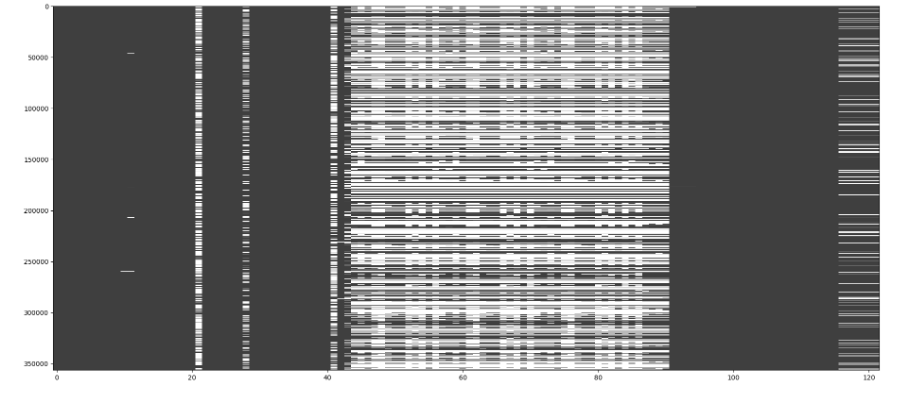

In [103]:
application_train_test.isna().sum().sum() / (application_train_test.shape[0] * application_train_test.shape[1])

np.float64(0.24289297291427145)

In [105]:
# feature engineering

# convert Y / N columns to boolean
application_train_test['FLAG_OWN_CAR'] = application_train_test['FLAG_OWN_CAR'].replace({'N':'0', 'Y':'1'})
application_train_test['FLAG_OWN_REALTY'] = application_train_test['FLAG_OWN_REALTY'].replace({'N':'0', 'Y':'1'})

application_train_test['DISPOSABLE_INCOME'] = application_train_test['AMT_INCOME_TOTAL'] - application_train_test['AMT_ANNUITY']
application_train_test['DISPOSABLE_INCOME_per_capita'] = application_train_test['DISPOSABLE_INCOME'] / application_train_test['CNT_FAM_MEMBERS']

# reduce number of occupation categories
blue_collar_jobs = ['Laborers', 'Sales staff', 'Core staff', 'Drivers', 'Security staff', 'Cooking staff', 'Cleaning staff',
                    'Private service staff', 'Low-skill Laborers', 'Waiters/barmen staff']
white_collar_jobs = ['Managers', 'High skill tech staff', 'Accountants', 'Secretaries', 'Medicine staff', 'Realty agents', 'HR staff',
                     'IT staff']
application_train_test.loc[application_train_test['OCCUPATION_TYPE'].isin(blue_collar_jobs), 'OCCUPATION_GROUPS'] = 'blue_collar'
application_train_test.loc[application_train_test['OCCUPATION_TYPE'].isin(white_collar_jobs), 'OCCUPATION_GROUPS'] = 'white_collar'

# reduce number of categories of people the applicant was accompanied by
# application_train_test.loc[application_train_test['NAME_TYPE_SUITE'] == 'Unaccompanied', 'ACCOMPANIED'] = 'unaccompanied'
# application_train_test.loc[((application_train_test['NAME_TYPE_SUITE'] == 'Family')
#                             | (application_train_test['NAME_TYPE_SUITE'] =='Spouse, partner')
#                             | (application_train_test['NAME_TYPE_SUITE'] =='Children')), 'ACCOMPANIED'] = 'close relative'
# application_train_test.loc[((application_train_test['NAME_TYPE_SUITE']== 'Other_B')
#                             | (application_train_test['NAME_TYPE_SUITE'] =='Other_A')
#                             | (application_train_test['NAME_TYPE_SUITE'] =='Group of people')), 'ACCOMPANIED'] = 'other'

# reduce munber of employment categories
fixed_salary = ['Working', 'State servant']
commission = ['Commercial associate', 'Businessman']
benefits = ['Pensioner', 'Unemployed', 'Student', 'Maternity leave']
application_train_test.loc[application_train_test['NAME_INCOME_TYPE'].isin(fixed_salary), 'INCOME_TYPE'] = 'fixed_salary'
application_train_test.loc[application_train_test['NAME_INCOME_TYPE'].isin(commission), 'INCOME_TYPE'] = 'commission'
application_train_test.loc[application_train_test['NAME_INCOME_TYPE'].isin(benefits), 'INCOME_TYPE'] = 'benefits'

# reduce number of education categories
secondary_or_lower = ['Secondary / secondary special', 'Lower secondary']
higher_or_tertiary = ['Higher education', 'Incomplete higher', 'Academic degree']
application_train_test.loc[application_train_test['NAME_EDUCATION_TYPE'].isin(secondary_or_lower), 'EDUCATION_TYPE'] = 'secondary_or_lower'
application_train_test.loc[application_train_test['NAME_EDUCATION_TYPE'].isin(higher_or_tertiary), 'EDUCATION_TYPE'] = 'higher_or_tertiary'

# reduce number of family status categories
married = ['Married', 'Civil marriage']
single_or_unknown = ['Single / not married', 'Separated', 'Widow', 'Unknown']
application_train_test.loc[application_train_test['NAME_FAMILY_STATUS'].isin(married), 'FAMILY_STATUS'] = 'married'
application_train_test.loc[application_train_test['NAME_FAMILY_STATUS'].isin(single_or_unknown), 'FAMILY_STATUS'] = 'single_or_unknown'

# reduce number of housing type categories
independent = ['House / apartment', 'Rented apartment', 'Office apartment']
social = ['With parents', 'Municipal apartment', 'Co-op apartment']
application_train_test.loc[application_train_test['NAME_HOUSING_TYPE'].isin(independent), 'HOUSING_TYPE'] = 'independent'
application_train_test.loc[application_train_test['NAME_HOUSING_TYPE'].isin(social), 'HOUSING_TYPE'] = 'social'

# amend age & employment columns
application_train_test['YEAR_BIRTH'] = application_train_test['DAYS_BIRTH'] * (-1) / 365
application_train_test['YEARS_EMPLOYED_AS_ADULT_%'] = (application_train_test['DAYS_EMPLOYED'] / 365) / (application_train_test['YEAR_BIRTH'] - 21)

# reduce number of phone columns
application_train_test.loc[((application_train_test['FLAG_MOBIL'] == 1) 
                            | (application_train_test['FLAG_EMP_PHONE'] == 1)
                            |(application_train_test['FLAG_WORK_PHONE'] == 1) 
                            |(application_train_test['FLAG_PHONE'] == 1)), 'PHONE_PROVIDED'] = 1
application_train_test.loc[(application_train_test['FLAG_CONT_MOBILE'] == 1), 'PHONE_REACHABLE'] = 1

# reduce number of columns indicating inconsistencies in the client's address details
application_train_test.loc[((application_train_test['REG_REGION_NOT_LIVE_REGION'] == 1)
                           | (application_train_test['REG_REGION_NOT_WORK_REGION'] == 1)
                           | (application_train_test['LIVE_REGION_NOT_WORK_REGION'] == 1)
                           | (application_train_test['REG_CITY_NOT_LIVE_CITY'] == 1)
                           | (application_train_test['REG_CITY_NOT_WORK_CITY'] == 1)
                           | (application_train_test['LIVE_CITY_NOT_WORK_CITY'] == 1)), 'ADDRESS_MISMATCH'] = 1

# reduce number of external credit ratings
application_train_test['CREDIT_RATING'] = (application_train_test['EXT_SOURCE_1'] + application_train_test['EXT_SOURCE_2'] + 
                                           application_train_test['EXT_SOURCE_3']) / 3


# reduce number of columns related to documents provided
application_train_test['NB_APPLICATION_DOCUMENTS_%'] = (application_train_test['FLAG_DOCUMENT_2'] + application_train_test['FLAG_DOCUMENT_3'] +
                                                     application_train_test['FLAG_DOCUMENT_4'] + application_train_test['FLAG_DOCUMENT_5'] +
                                                     application_train_test['FLAG_DOCUMENT_6'] + application_train_test['FLAG_DOCUMENT_7'] +
                                                     application_train_test['FLAG_DOCUMENT_8'] + application_train_test['FLAG_DOCUMENT_9'] +
                                                     application_train_test['FLAG_DOCUMENT_21'] + application_train_test['FLAG_DOCUMENT_10'] +
                                                     application_train_test['FLAG_DOCUMENT_11'] + application_train_test['FLAG_DOCUMENT_12'] +
                                                     application_train_test['FLAG_DOCUMENT_13'] + application_train_test['FLAG_DOCUMENT_14'] +
                                                     application_train_test['FLAG_DOCUMENT_15'] + application_train_test['FLAG_DOCUMENT_16'] +
                                                     application_train_test['FLAG_DOCUMENT_17'] + application_train_test['FLAG_DOCUMENT_18'] +
                                                     application_train_test['FLAG_DOCUMENT_19'] + application_train_test['FLAG_DOCUMENT_20']) / 20

# reduce numer of columns about enquiries made about client
application_train_test['REQUESTS_ABOUT_CLIENT_1Y'] = (application_train_test['AMT_REQ_CREDIT_BUREAU_HOUR'] +
                                                      application_train_test['AMT_REQ_CREDIT_BUREAU_DAY'] +
                                                      application_train_test['AMT_REQ_CREDIT_BUREAU_WEEK'] +
                                                      application_train_test['AMT_REQ_CREDIT_BUREAU_MON'] +
                                                      application_train_test['AMT_REQ_CREDIT_BUREAU_QRT'] +
                                                      application_train_test['AMT_REQ_CREDIT_BUREAU_YEAR'])

# reduce number of ORGANIZATION_TYPE categories
primary = ['Agriculture']
secondary = ['Electricity', 'Construction', 'Housing','Industry: type 11','Industry: type 1', 'Industry: type 4','Industry: type 7',
            'Industry: type 3','Industry: type 9','Industry: type 2','Industry: type 12','Industry: type 5', 'Industry: type 10',
             'Industry: type 13','Industry: type 8','Industry: type 6']
tertiary = ['Business Entity Type 3','Medicine','Business Entity Type 2','Transport: type 2','Trade: type 7','Services','Transport: type 4',
           'Security','Trade: type 2','Transport: type 3','Business Entity Type 1','Restaurant','Hotel','Trade: type 3','Bank','Insurance', 
           'Trade: type 6','Transport: type 1','Mobile','Trade: type 1', 'Legal Services', 'Advertising', 'Trade: type 5', 'Cleaning',
           'School','Religion','Kindergarten', 'University','Culture', 'Trade: type 4', 'Telecom','Realtor']
government = ['Government', 'Military', 'Security Ministries','Emergency','Police','Postal']
other = ['Other', 'XNA', 'Self-employed']
application_train_test.loc[application_train_test['ORGANIZATION_TYPE'].isin(primary), 'EMPLOYMENT_SECTOR'] = 'primary'
application_train_test.loc[application_train_test['ORGANIZATION_TYPE'].isin(secondary), 'EMPLOYMENT_SECTOR'] = 'secondary'
application_train_test.loc[application_train_test['ORGANIZATION_TYPE'].isin(tertiary), 'EMPLOYMENT_SECTOR'] = 'tertiary'
application_train_test.loc[application_train_test['ORGANIZATION_TYPE'].isin(government), 'EMPLOYMENT_SECTOR'] = 'government'
application_train_test.loc[((application_train_test['ORGANIZATION_TYPE'].isin(other)) 
                            | (application_train_test['ORGANIZATION_TYPE'].isna())), 'EMPLOYMENT_SECTOR'] = 'other'

In [106]:
# remove redundant columns
application_train_test.drop(labels=['OCCUPATION_TYPE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                                    'DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                                    'FLAG_PHONE', 'FLAG_CONT_MOBILE', 'HOUR_APPR_PROCESS_START', 'WEEKDAY_APPR_PROCESS_START',
                                    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
                                    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 
                                    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'CNT_CHILDREN', 'DAYS_EMPLOYED',
                                    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG','COMMONAREA_AVG',
                                    'ELEVATORS_AVG','ENTRANCES_AVG','FLOORSMAX_AVG','FLOORSMIN_AVG','LANDAREA_AVG',
                                    'LIVINGAPARTMENTS_AVG','LIVINGAREA_AVG','NONLIVINGAPARTMENTS_AVG','NONLIVINGAREA_AVG',
                                    'APARTMENTS_MODE','BASEMENTAREA_MODE','YEARS_BEGINEXPLUATATION_MODE','YEARS_BUILD_MODE',
                                    'COMMONAREA_MODE','ELEVATORS_MODE','ENTRANCES_MODE','FLOORSMAX_MODE','FLOORSMIN_MODE',
                                    'LANDAREA_MODE','LIVINGAPARTMENTS_MODE','LIVINGAREA_MODE','NONLIVINGAPARTMENTS_MODE',
                                    'NONLIVINGAREA_MODE','APARTMENTS_MEDI','BASEMENTAREA_MEDI','YEARS_BEGINEXPLUATATION_MEDI',
                                    'YEARS_BUILD_MEDI','COMMONAREA_MEDI','ELEVATORS_MEDI','ENTRANCES_MEDI',
                                    'FLOORSMAX_MEDI','FLOORSMIN_MEDI','LANDAREA_MEDI','LIVINGAPARTMENTS_MEDI',
                                    'LIVINGAREA_MEDI','NONLIVINGAPARTMENTS_MEDI','NONLIVINGAREA_MEDI','FONDKAPREMONT_MODE',
                                    'TOTALAREA_MODE','EMERGENCYSTATE_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',
                                    'FLAG_DOCUMENT_2','FLAG_DOCUMENT_3','FLAG_DOCUMENT_4','FLAG_DOCUMENT_5','FLAG_DOCUMENT_6',
                                    'FLAG_DOCUMENT_7','FLAG_DOCUMENT_8','FLAG_DOCUMENT_9','FLAG_DOCUMENT_10','FLAG_DOCUMENT_11',
                                    'FLAG_DOCUMENT_12','FLAG_DOCUMENT_13','FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16',
                                    'FLAG_DOCUMENT_17','FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21',
                                    'AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_WEEK',
                                    'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT','AMT_REQ_CREDIT_BUREAU_YEAR',
                                    'ORGANIZATION_TYPE', 'NAME_EDUCATION_TYPE', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE'
                                    ], axis=1, inplace=True)

In [107]:
print(application_train_test.shape)
application_train_test.sample(5)

(356255, 36)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,OCCUPATION_GROUPS,INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,EMPLOYMENT_SECTOR
41441,147976,0,Revolving loans,F,0,1,135000.0,6750.0,135000.0,0.019689,-3018.0,-3883,0,2,2,0.0,0.0,0.0,0.0,-1001.0,38250.0,12750.0,blue_collar,fixed_salary,secondary_or_lower,married,independent,32.572603,-0.410985,1.0,1.0,1.0,NaN,0.00,NaN,other
76736,188984,1,Cash loans,F,0,1,311877.0,15921.0,252000.0,0.020246,-2725.0,-818,1,3,3,0.0,0.0,0.0,0.0,-2119.0,74079.0,74079.0,blue_collar,fixed_salary,secondary_or_lower,single_or_unknown,independent,47.364384,-0.089889,1.0,1.0,NaN,0.490631,0.05,2.0,tertiary
57772,166954,0,Cash loans,F,0,0,450000.0,21888.0,450000.0,0.028663,-1100.0,-4807,0,2,2,1.0,0.0,1.0,0.0,-3107.0,27612.0,13806.0,NaN,fixed_salary,higher_or_tertiary,married,independent,37.550685,-0.295977,1.0,1.0,1.0,0.596248,0.05,3.0,other
946,101093,1,Cash loans,F,0,1,152820.0,17370.0,135000.0,0.011703,-6104.0,-692,0,2,2,0.0,0.0,0.0,0.0,-82.0,149130.0,74565.0,white_collar,commission,secondary_or_lower,married,independent,24.882192,-0.880028,1.0,1.0,1.0,0.172044,0.05,7.0,secondary
52391,160670,0,Cash loans,M,1,1,45000.0,5220.0,45000.0,0.015221,-782.0,-1906,0,2,2,5.0,0.0,5.0,0.0,0.0,168030.0,56010.0,blue_collar,fixed_salary,higher_or_tertiary,married,independent,25.312329,-0.416137,1.0,1.0,NaN,NaN,0.05,0.0,tertiary


In [108]:
msno.matrix(application_train_test)

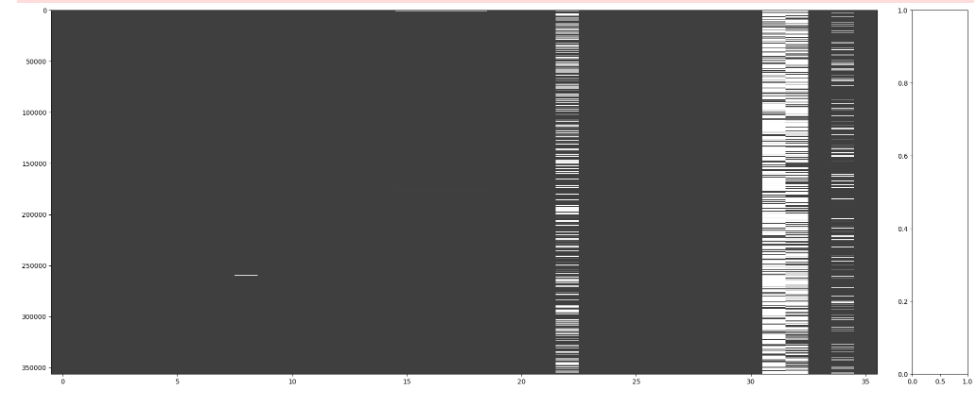

- **Merge all files:**

In [109]:
merged_data_raw = application_train_test.merge(grouped_data_1_3, how='left', left_on='SK_ID_CURR', right_on='b_SK_ID_CURR').merge(grouped_data_1_4, how='left', left_on='SK_ID_CURR', right_on='pcb_SK_ID_CURR').merge(grouped_data_1_5, how='left', left_on='SK_ID_CURR', right_on='ccb_SK_ID_CURR').merge(grouped_data_1_6, how='left', left_on='SK_ID_CURR', right_on='ip_SK_ID_CURR').merge(grouped_data_1_7, how='left', left_on='SK_ID_CURR', right_on='pa_SK_ID_CURR')

In [110]:
merged_data_raw.shape

(356255, 98)

In [111]:
merged_data_raw.isna().sum().sum() / (merged_data_raw.shape[0] * merged_data_raw.shape[1])

np.float64(0.1652380961928497)

In [112]:
sample_merged_data_raw = merged_data_raw.head(10)
sample_merged_data_raw.to_csv('sample_merged_data_raw.csv', index=False)

In [113]:
# sum / merge columns
merged_data_raw['TOTAL_APPROVED_CREDITS'] = (merged_data_raw['b_NB_PREVIOUS_APPROVED_CREDITS'] 
                                            +  merged_data_raw['pcb_NB_PREVIOUS_APPROVED_CASH_LOANS'] 
                                            + merged_data_raw['pa_BANK_APPROVED_sum'])

merged_data_raw['TOTAL_PAYMENT_DELAYS_DAYS'] =  (merged_data_raw['b_CREDIT_DAY_OVERDUE_sum'] + merged_data_raw['bb_DPD_mean']
                                                + merged_data_raw['pcb_SK_DPD_AVG_mean']
                                                + merged_data_raw['ccb_SK_DPD_ADJ_mean'])

merged_data_raw['TOTAL_ACTIVE_CAR_LOANS'] = merged_data_raw['pa_CAR_LOAN_sum'] + merged_data_raw['b_TYPE_CAR_LOAN_sum']

merged_data_raw['TOTAL_ACTIVE_OTHER_LOANS'] = merged_data_raw['pa_OTHER_LOAN_TYPE_sum'] + merged_data_raw['b_OTHER_CREDIT_TYPE_sum']

merged_data_raw['TOTAL_ACTIVE_CONSUMER_LOANS'] = merged_data_raw['pa_CONSUMER_LOAN_TYPE_sum'] + merged_data_raw['b_TYPE_CONSUMER_CREDIT_sum']

merged_data_raw['TOTAL_ACTIVE_MICRO_LOANS'] = merged_data_raw['pa_MICRO_LOAN_TYPE_sum'] + merged_data_raw['b_TYPE_MICROLOAN_sum']	

merged_data_raw['TOTAL_ACTIVE_MORTGAGES'] = merged_data_raw['b_TYPE_MORTGAGE_sum'] + merged_data_raw['pa_MORTGAGE_LOAN_TYPE_sum']

merged_data_raw['TOTAL_ACTIVE_CREDIT_CARDS'] = merged_data_raw['b_TYPE_CREDIT_CARD_sum'] + merged_data_raw['ccb_NUMBER_OF_CREDIT_CARDS_CREDITS']

merged_data_raw['TOTAL_CURRENT_ANNUITIES']	= 	(merged_data_raw['b_CREDIT_ANNUITY_sum']	 + merged_data_raw['ip_AMT_ANNUITY_sum']
                                                 + merged_data_raw['b_CREDIT_AMT_USED_sum'])

merged_data_raw['DEBT_RENEGOCIATIONS'] = merged_data_raw['b_CNT_CREDIT_PROLONG_sum'] + merged_data_raw['ccb_MIN_PMT_NOT_MET_sum']

merged_data_raw['CLIENT_BAD_CREDIT_HISTORY'] = (merged_data_raw['b_CREDIT_SOLD_sum'] + merged_data_raw['b_BAD_DEBT_sum']
                                               +merged_data_raw['pa_CREDIT_SCORE_ISSUE_sum'] + merged_data_raw['pa_CREDIT_LIMIT_ISSUE_sum'])

merged_data_raw['CLIENT_FRAUD_FLAG'] = 	merged_data_raw['pa_CREDIT_ID_ISSUE_sum'] + merged_data_raw['pa_OTHER_ISSUE_sum']

merged_data_raw['CLIENT_WITHDRAWN_APPLICATIONS'] = merged_data_raw['pa_CLIENT_CANCELED_sum'] + merged_data_raw['pa_UNUSED_BY_CLIENT_sum']

merged_data_raw['DOWN_PAYMENT_CURR_%'] = ((merged_data_raw['AMT_GOODS_PRICE'] - merged_data_raw['AMT_CREDIT'])
                                          / merged_data_raw['AMT_GOODS_PRICE'])

merged_data_raw['DEBT_RATE_INC_CURR_%'] = ((merged_data_raw['AMT_ANNUITY']	+ merged_data_raw['TOTAL_CURRENT_ANNUITIES'])
                                         / merged_data_raw['DISPOSABLE_INCOME'] )

merged_data_raw.loc[merged_data_raw['CODE_GENDER'] == 'M', 'IS_MALE'] = 1
merged_data_raw.loc[merged_data_raw['CODE_GENDER'] == 'F', 'IS_MALE'] = 0

merged_data_raw.loc[merged_data_raw['OCCUPATION_GROUPS'] == 'white_collar', 'WHITE_COLLAR'] = 1
merged_data_raw.loc[merged_data_raw['OCCUPATION_GROUPS'] == 'blue_collar', 'WHITE_COLLAR'] = 0

merged_data_raw.loc[merged_data_raw['EDUCATION_TYPE'] == 'higher_or_tertiary', 'UPPER_EDUCATION'] = 1
merged_data_raw.loc[merged_data_raw['EDUCATION_TYPE'] == 'secondary_or_lower', 'UPPER_EDUCATION'] = 0

merged_data_raw.loc[merged_data_raw['FAMILY_STATUS'] == 'married', 'IS_MARRIED'] = 1
merged_data_raw.loc[merged_data_raw['FAMILY_STATUS'] == 'single_or_unknown', 'IS_MARRIED'] = 0

merged_data_raw.loc[merged_data_raw['HOUSING_TYPE'] == 'independent', 'LIVES_INDEPENDENTLY'] = 1
merged_data_raw.loc[merged_data_raw['HOUSING_TYPE'] == 'social', 'LIVES_INDEPENDENTLY'] = 0

In [114]:
# drop columns with duplicate identifiers or which have been aggregated
merged_data_raw = merged_data_raw.drop(labels =['b_SK_ID_CURR',
                                                'pcb_SK_ID_CURR',
                                                'ccb_SK_ID_CURR',
                                                'pa_SK_ID_CURR',
                                                'ip_SK_ID_CURR',
                                                'b_NB_PREVIOUS_APPROVED_CREDITS',
                                                'pcb_NB_PREVIOUS_APPROVED_CASH_LOANS',
                                                'pa_BANK_APPROVED_sum',
                                                'b_CREDIT_DAY_OVERDUE_sum',
                                                'bb_DPD_mean',
                                                'pcb_SK_DPD_AVG_mean',
                                                'ccb_SK_DPD_ADJ_mean',
                                                'pa_INTEREST_RATE_mean',
                                                'pa_CAR_LOAN_sum',
                                                'pa_OTHER_LOAN_TYPE_sum',
                                                'pa_CONSUMER_LOAN_TYPE_sum',
                                                'pa_MICRO_LOAN_TYPE_sum',
                                                'pa_MORTGAGE_LOAN_TYPE_sum',
                                                'b_TYPE_CONSUMER_CREDIT_sum',
                                                'b_TYPE_CREDIT_CARD_sum',
                                                'b_TYPE_CAR_LOAN_sum',
                                                'b_TYPE_MORTGAGE_sum',
                                                'b_TYPE_MICROLOAN_sum',
                                                'b_OTHER_CREDIT_TYPE_sum',
                                                'ccb_NUMBER_OF_CREDIT_CARDS_CREDITS',
                                                'pa_NUMBER_ACTIVE_LOANS',
                                                'ip_NB_CURRENT_ACTIVE_CREDITS',
                                                'b_CREDIT_ANNUITY_sum',
                                                'ip_AMT_ANNUITY_sum',
                                                'b_CREDIT_AMT_GRANTED_sum',
                                                'b_CREDIT_AMT_USED_sum',
                                                'b_CNT_CREDIT_PROLONG_sum',
                                                'ccb_MIN_PMT_NOT_MET_sum',
                                                'b_CREDIT_SOLD_sum',
                                                'b_BAD_DEBT_sum',
                                                'pa_CLIENT_CANCELED_sum',
                                                'pa_UNUSED_BY_CLIENT_sum',
                                                'pa_CREDIT_SCORE_ISSUE_sum',
                                                'pa_CREDIT_LIMIT_ISSUE_sum',
                                                'pa_CREDIT_ID_ISSUE_sum',
                                                'pa_OTHER_ISSUE_sum',
                                                'AMT_GOODS_PRICE',
                                                'AMT_ANNUITY',
                                                'TOTAL_CURRENT_ANNUITIES',
                                                'CODE_GENDER',
                                                'OCCUPATION_GROUPS',
                                                'EDUCATION_TYPE',
                                                'FAMILY_STATUS',
                                                'HOUSING_TYPE'                                                
                                               ], axis=1)                                       

In [115]:
merged_data_raw.shape

(356255, 69)

In [116]:
merged_data_raw.isna().sum().sum() / (merged_data_raw.shape[0] * merged_data_raw.shape[1])

np.float64(0.1823336931553872)

In [117]:
# fill NaNs with zeros in columns from credit_card_balance.csv => clients found in train/test but not in credit card file
# just don't have a credit card
merged_data_raw[['ccb_AMT_BALANCE_mean', 'ccb_AMT_CREDIT_LIMIT_ACTUAL_mean', 'ccb_AMT_DRAWINGS_TOTAL_mean', 'ccb_AMT_TOTAL_RECEIVABLE_mean', \
                 'ccb_TOTAL_INSTALMENTS_max', 'ccb_CNT_DRAWINGS_TOTAL_mean', 'ccb_CARD_OVERDRAWN_sum', 'ccb_CARD_OVERDRAWN_%_mean',]] \
                 = merged_data_raw[['ccb_AMT_BALANCE_mean', 'ccb_AMT_CREDIT_LIMIT_ACTUAL_mean', 'ccb_AMT_DRAWINGS_TOTAL_mean',\
                 'ccb_AMT_TOTAL_RECEIVABLE_mean', 'ccb_TOTAL_INSTALMENTS_max', 'ccb_CNT_DRAWINGS_TOTAL_mean', 'ccb_CARD_OVERDRAWN_sum',\
                 'ccb_CARD_OVERDRAWN_%_mean']].fillna(value=0, axis=1)

In [118]:
merged_data_raw.sample(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,INCOME_TYPE,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,EMPLOYMENT_SECTOR,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
345847,381469,UNKNOWN,Cash loans,0,1,108000.0,0.019101,-4962.0,-328,0,2,2,2.0,2.0,2.0,2.0,-992.0,149143.5,37285.875,commission,28.380822,-1.377134,1.0,1.0,1.0,0.229113,0.05,3.0,tertiary,4491.0,0.0,12.0,58607.487,117000.0,31518.819,57287.2275,8.0,9.7,0.0,0.0,0.00,4.500000,0.000000,0.00,57168.000,0.072786,0.0,6.0,12.771026,6.0,21.0,0.258599,1.0,3.0,7.0,0.0,0.0,1.0,2.0,6.0,4.0,2.0,0.0000,29.147346,0.0,0.0,0.0,1.0,1.0
15608,118215,0,Cash loans,0,0,161730.0,0.008474,-4948.0,-2866,0,2,2,0.0,0.0,0.0,0.0,-487.0,35230.5,17615.250,fixed_salary,28.147945,-0.732848,1.0,1.0,NaN,0.332288,0.05,2.0,government,0.0,0.0,6.0,0.000,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.00,6.833333,0.000000,0.00,23829.750,0.054575,0.0,0.0,4.982523,2.0,6.0,NaN,0.0,0.0,3.0,0.0,0.0,NaN,NaN,0.0,1.0,1.0,-0.1980,7.151917,0.0,0.0,0.0,1.0,0.0
317294,171065,UNKNOWN,Cash loans,0,1,341280.0,0.031329,-9078.0,-5128,0,2,2,5.0,0.0,5.0,0.0,0.0,81562.5,27187.500,fixed_salary,41.071233,-0.898444,1.0,1.0,NaN,NaN,0.05,1.0,secondary,0.0,0.0,10.0,0.000,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.00,21.769231,0.000000,0.00,96307.875,0.026461,1.0,0.0,7.039586,3.0,11.0,NaN,0.0,0.0,4.0,0.0,0.0,NaN,NaN,0.0,2.0,2.0,-0.2640,25.524420,1.0,0.0,0.0,1.0,1.0
97684,213422,0,Cash loans,1,1,528633.0,0.019689,-4884.0,-3197,0,2,2,1.0,1.0,1.0,1.0,-408.0,85378.5,42689.250,fixed_salary,30.520548,-0.347914,1.0,1.0,NaN,0.348443,0.05,1.0,other,81198.0,0.0,30.0,0.000,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.00,11.769231,0.000000,0.00,499995.000,0.108909,0.0,0.0,22.497165,1.0,8.0,NaN,1.0,0.0,1.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,-0.1188,36.865059,0.0,0.0,1.0,1.0,1.0
48464,156127,0,Cash loans,0,0,269550.0,0.008866,-5975.0,-4031,0,2,2,0.0,0.0,0.0,0.0,-1036.0,93609.0,46804.500,benefits,66.068493,22.203222,1.0,1.0,NaN,0.654238,0.05,1.0,other,18859.5,0.0,24.0,0.000,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,2.66,7.920000,0.133413,0.12,82800.000,0.149095,1.0,0.0,12.116520,2.0,10.0,NaN,0.0,1.0,2.0,0.0,0.0,NaN,NaN,0.0,3.0,0.0,-0.1980,37.900746,0.0,NaN,0.0,1.0,1.0


In [119]:
merged_data_raw.to_csv('merged_data_raw_070325.csv', index=False)

In [120]:
merged_data_raw['TARGET'].value_counts(dropna=False)

TARGET
0          282686
UNKNOWN     48744
1           24825
Name: count, dtype: int64

In [121]:
train_data_raw = merged_data_raw.loc[merged_data_raw['TARGET'] != 'UNKNOWN']
print(train_data_raw.shape)
train_data_raw.to_csv('train_data_raw.csv', index=False, header=True, encoding='utf-8')

(307511, 69)


In [122]:
test_data_raw = merged_data_raw.loc[merged_data_raw['TARGET'] == 'UNKNOWN']
print(test_data_raw.shape)
test_data_raw.to_csv('test_data_raw.csv', index=False, header=True, encoding='utf-8')

(48744, 69)


## 1.10 - File sample_submission.csv

In [123]:
sample_submission = pd.read_csv('sample_submission.csv', sep=',', encoding='latin-1', engine='pyarrow')
print(sample_submission.shape)
sample_submission.head()

(48744, 2)


,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5


In [124]:
application_test.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,UNKNOWN,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,UNKNOWN,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,UNKNOWN,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,UNKNOWN,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Workin

In [125]:
list_a = sample_submission['SK_ID_CURR'].unique().tolist()

In [126]:
list_b = application_test['SK_ID_CURR'].unique().tolist()

In [127]:
isInList(list_a, list_b)

[]

In [128]:
isInList(list_b, list_a)

[]

In [129]:
sample_submission.isna().sum().sum() / (sample_submission.shape[0] * sample_submission.shape[1])

np.float64(0.0)

**This file is just a template of what the prediction on the test set should look like where the target is a dummy (0.5 everywhere) => table is not required for training or prediction.**